# Load Dataset

In [2]:
import scanpy as sc
import scanpy.external as sce
# import scvelo as scv
# import cellrank as cr
# from cellrank.kernels import CytoTRACEKernel

import numpy as np

In [3]:
import palantir
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
region = 'Neurogenesis'
sc.settings.figdir = f"./figures_logCPM/{region}/05282026/"

In [5]:
# !pip install anndata>=0.10.0

In [6]:
adata = sc.read_h5ad('../Neurogenesis_PCells_processed_basedSample_modified.h5ad')
# adata = sc.read_h5ad('../Neurogenesis_PCells_processed_basedSample_modified.h5ad
# adata.X = adata.layers['logCPM']
adata

AnnData object with n_obs × n_vars = 133088 × 4998
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellCycleFraction', 'DoubletFlag', 'DoubletScore', 'Subdivision', 'Subregion', 'Tissue', 'TopLevelCluster', 'TotalUMIs', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'total_UMIs', 'sample_id', 'cluster_id', 'class', 'region', 'donor', 'sample', 'cell_ID.1', 'OldCellID', 'n_genes', 'mainRegion', 'Age'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_PCA_for_Harmony', 'X_UMAP_RNA_Harmony', 'X_UMAP_RNA_Harmony_3D', 'X_harmony'
    varm: 'HARMONY', 'PCA_FOR_HARMONY'

In [7]:
n_pcs=50
n_neighbors=100
sc.pp.neighbors(adata,n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=0, use_rep='X_harmony')

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


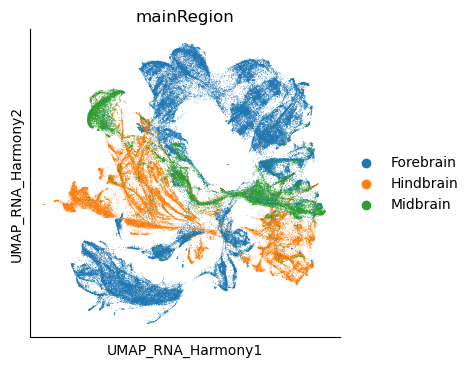

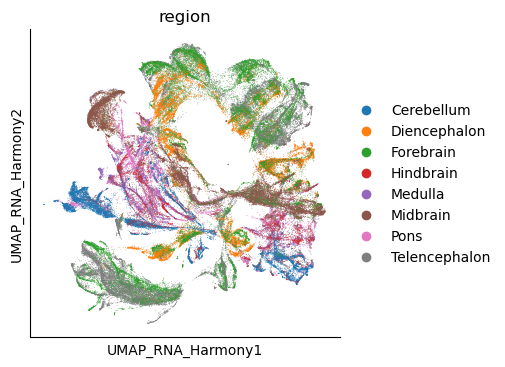

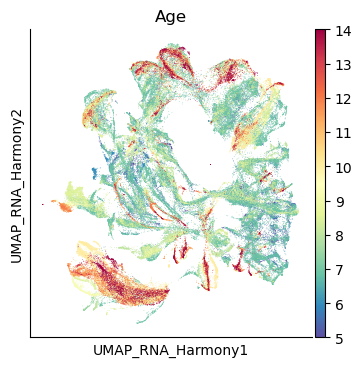

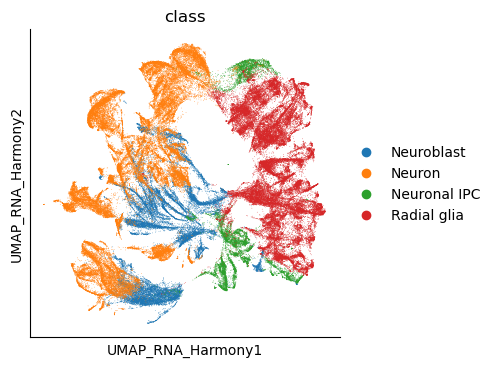

In [8]:
for c in ['mainRegion', 'region', 'Age', 'class']:#,'pseudotime']:
    sc.pl.embedding(adata, basis="UMAP_RNA_Harmony", 
                    color=c, save=f'_{c}.pdf',)

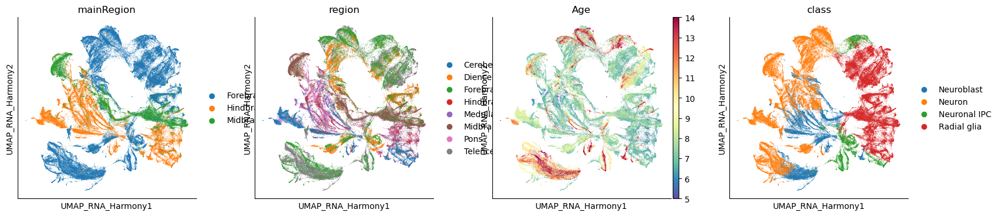

In [9]:
sc.pl.embedding(adata, basis="UMAP_RNA_Harmony", 
                color=['mainRegion', 'region', 'Age', 'class'], )

In [10]:
adata.obs['mainRegion'].value_counts()

mainRegion
Forebrain    75180
Hindbrain    35968
Midbrain     21940
Name: count, dtype: int64

In [11]:
def subsample_and_analyze(data, n_pcs, n_neighbors, cell_idx, n_iterations=4):
    results = []
    for i in range(n_iterations):
        adata_sub = data.copy()
        print((cell_idx).shape)
        sc.pp.neighbors(adata_sub, n_pcs=n_pcs, n_neighbors=n_neighbors, use_rep='X_harmony', random_state=i)
        early_cell = adata_sub.obs_names[cell_idx[i]]
        print(early_cell)

        palantir.plot.highlight_cells_on_umap(adata_sub, [early_cell], embedding_basis='X_UMAP_RNA_Harmony')
        plt.show()
        
        sce.tl.palantir(adata_sub, n_components=n_pcs, use_adjacency_matrix=True)    
        pr_res = sce.tl.palantir_results(
            adata_sub,
            early_cell=early_cell,
            ms_data='X_palantir_multiscale',
        )
        print(pr_res.pseudotime.values)
        results.append({f'subsample_{i}': pr_res.pseudotime.values.copy()})

        print("Done")
    
    return results

(2743,)
10X178_2:AGGACGATCTCGTGGG


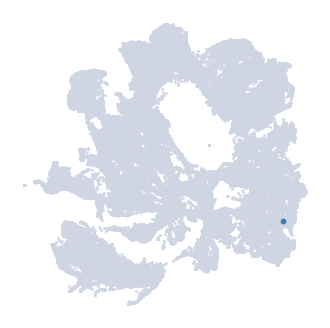

In [12]:

condition = np.where((adata.obs['Age']==np.min(adata.obs['Age']))&
                     (adata.obs['class']=='Radial glia'))[0]
print(condition.shape)
start_cell = adata.obs_names[condition[0]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata, [start_cell], embedding_basis='X_UMAP_RNA_Harmony')
plt.show()

In [13]:
sce.tl.palantir(adata, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
adata.obs['pr_pseudotime']=pr_res.pseudotime

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.08724470138549804 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.9344088673591613 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9992
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


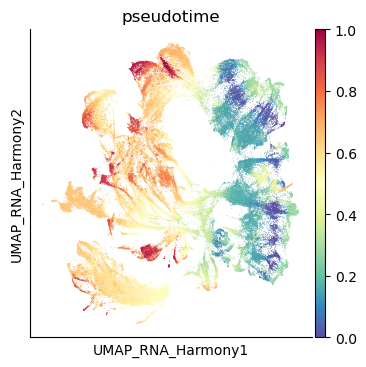

In [14]:
adata.obs['pseudotime']=pr_res.pseudotime
sc.pl.embedding(adata, basis="UMAP_RNA_Harmony", 
                color=['pseudotime'], )

# Forebrain

In [15]:
adata_Forebrain = adata[adata.obs['mainRegion'] == 'Forebrain'].copy()
# adata_Forebrain.write_h5ad('Forebrain.h5ad')
# del adata_Forebrain

In [16]:
sc.pp.neighbors(adata_Forebrain,use_rep='X_harmony', n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=42)
sc.tl.umap(adata_Forebrain)

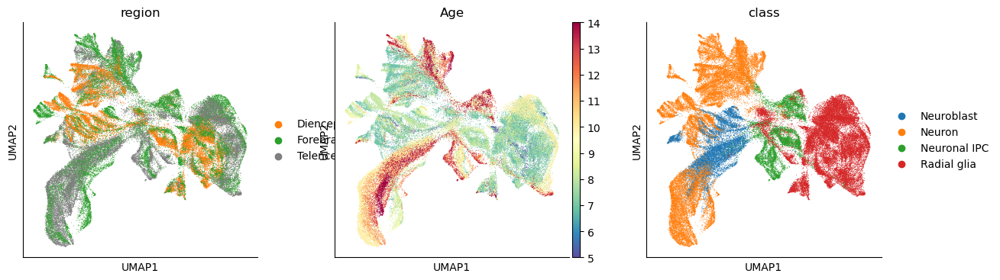

In [17]:
sc.pl.embedding(adata_Forebrain, basis="umap", 
                color=['region', 'Age', 'class'], )

## Palantir

(1,)
10X177_4:GAGTTACCAAGTAGTA


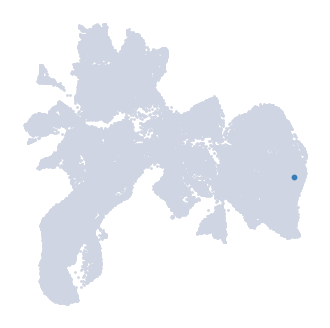

In [18]:
q0 = np.quantile(adata_Forebrain.obsm['X_umap'][:,0],0.98)

condition = np.where((adata_Forebrain.obs['Age']==np.min(adata_Forebrain.obs['Age']))&
                     (adata_Forebrain.obs['class']=='Radial glia')&(adata_Forebrain.obsm['X_umap'][:,0]>q0))[0]
print(condition.shape)
start_cell = adata_Forebrain.obs_names[condition[-1]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata_Forebrain, [start_cell])
plt.show()

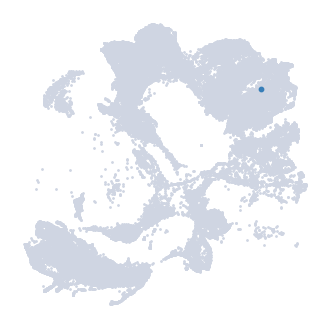

In [19]:
palantir.plot.highlight_cells_on_umap(adata_Forebrain, [start_cell],embedding_basis='X_UMAP_RNA_Harmony')
plt.show()

In [20]:
sce.tl.palantir(adata_Forebrain, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Forebrain,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
adata_Forebrain.obs['pr_pseudotime']=pr_res.pseudotime

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.047828582922617595 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.0848283489545187 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9993
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


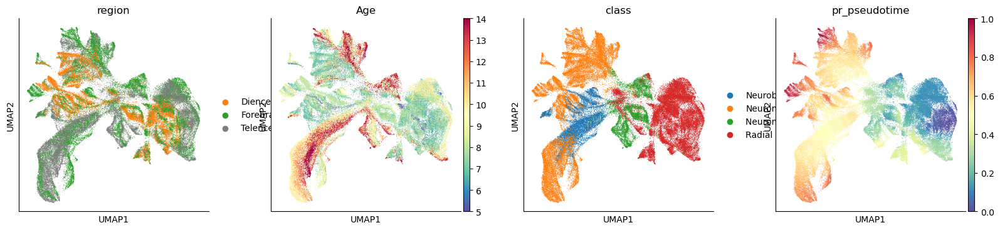

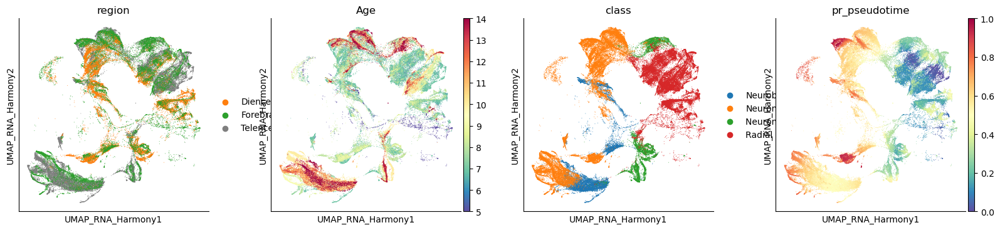

In [21]:
sc.pl.embedding(adata_Forebrain, basis="umap", 
                color=['region', 'Age', 'class','pr_pseudotime'], )
sc.pl.embedding(adata_Forebrain, basis="UMAP_RNA_Harmony", 
                color=['region', 'Age', 'class','pr_pseudotime'], )

In [22]:
print(adata_Forebrain.obs['pr_pseudotime'])

10X89_1:AACCATGTCGATGAGG     0.490665
10X89_1:AACTCCCGTAGATTAG     0.497524
10X89_1:AACTCCCGTCTCTTTA     0.536190
10X89_1:AAGGCAGGTTCGCGAC     0.514784
10X89_1:AAGTCTGCATGACGGA     0.574199
                               ...   
10X115_6:GAGGTGAGTAGTGAAT    0.047921
10X115_6:GGGTCTGTCACGCGGT    0.399667
10X115_6:GTTAAGCCAAAGCGGT    0.482010
10X115_6:TGGCGCAAGAGCCTAG    0.052491
10X115_6:GGGAGATCAGACAGGT    0.041329
Name: pr_pseudotime, Length: 75180, dtype: float64


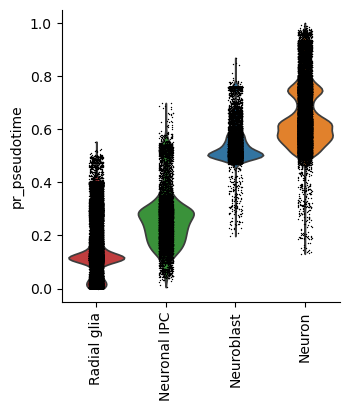

In [23]:
trajectory = ['Radial glia', 'Neuronal IPC','Neuroblast','Neuron']
# plot the Monocyte trajectory
mask = np.in1d(adata_Forebrain.obs["class"], trajectory)
sc.pl.violin(
    adata_Forebrain[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
    save=f"_{region}_Forebrain_v3_05282026.png"
)

## Cellrank

In [24]:
import cellrank as cr
pk = cr.kernels.PseudotimeKernel(adata_Forebrain, time_key="pr_pseudotime")
pk.compute_transition_matrix()#frac_to_keep=0.1)#threshold_scheme="soft", nu=0.5)

100%|██████████| 75180/75180 [00:14<00:00, 5368.86cell/s]


PseudotimeKernel[n=75180, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [25]:
adata_Forebrain.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellCycleFraction',
       'DoubletFlag', 'DoubletScore', 'Subdivision', 'Subregion', 'Tissue',
       'TopLevelCluster', 'TotalUMIs', 'organism_ontology_term_id',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'assay_ontology_term_id', 'sex_ontology_term_id',
       'development_stage_ontology_term_id', 'donor_id', 'suspension_type',
       'dissection', 'total_UMIs', 'sample_id', 'cluster_id', 'class',
       'region', 'donor', 'sample', 'cell_ID.1', 'OldCellID', 'n_genes',
       'mainRegion', 'Age', 'pr_pseudotime', 'pseudotime'],
      dtype='object')

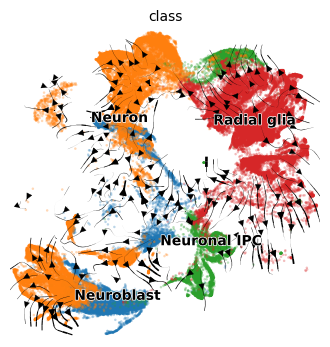

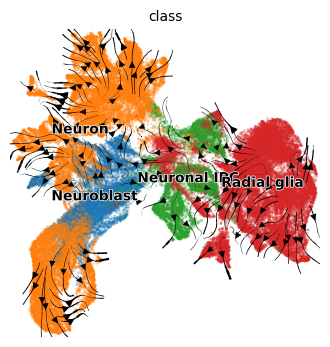

In [26]:
pk.plot_projection(basis="UMAP_RNA_Harmony",color='class')
pk.plot_projection(basis="umap",color='class')

[jies-mac-studio.local:89230] shmem: mmap: an error occurred while determining whether or not /var/folders/d9/00bghqkj3v5gz7ql52bz871h0000gn/T//ompi.jies-mac-studio.501/jf.0/1530331136/sm_segment.jies-mac-studio.501.5b370000.0 could be created.
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/

saving figure to file ./figures/scvelo_macrostates_all_umap_Neurogenesis_nn100_npc50.png


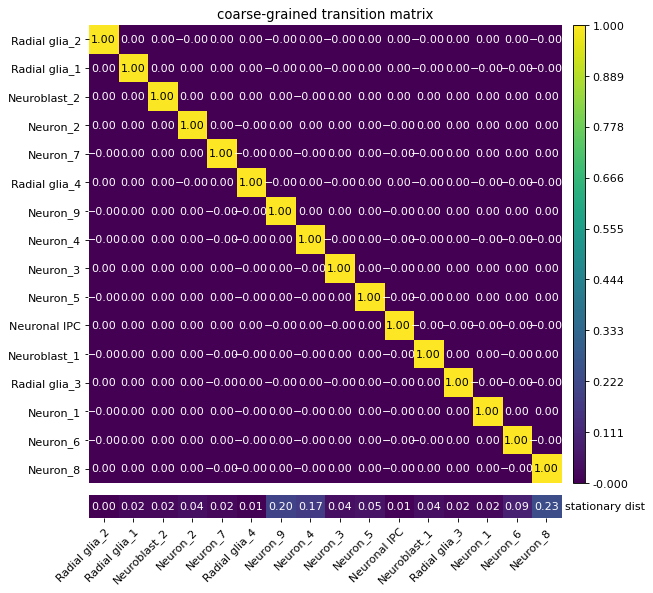

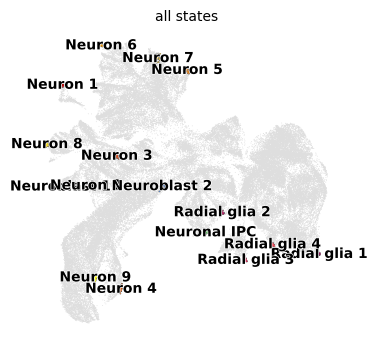

Neuron_1         30
Radial glia_1    30
Radial glia_2    30
Neuroblast_1     30
Neuron_2         30
Neuron_3         30
Neuron_4         30
Neuron_5         30
Neuronal IPC     30
Neuron_6         30
Radial glia_3    30
Radial glia_4    30
Neuron_7         30
Neuron_8         30
Neuroblast_2     30
Neuron_9         30
Name: count, dtype: int64


/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


saving figure to file ./figures/scvelo_macrostates_all_UMAP_RNA_Harmony_Neurogenesis_nn100_npc50.png


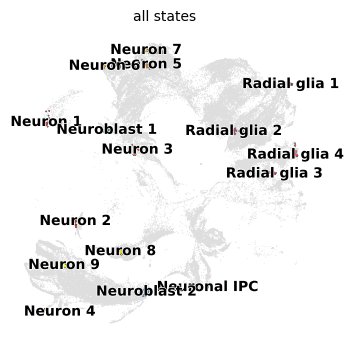

Neuron_1         30
Radial glia_1    30
Radial glia_2    30
Neuroblast_1     30
Neuron_2         30
Neuron_3         30
Neuron_4         30
Neuron_5         30
Neuronal IPC     30
Neuron_6         30
Radial glia_3    30
Radial glia_4    30
Neuron_7         30
Neuron_8         30
Neuroblast_2     30
Neuron_9         30
Name: count, dtype: int64


In [27]:
from cellrank.estimators import GPCCA
g = GPCCA(pk)
g.fit(cluster_key="class", n_states=[12,18])
g.plot_coarse_T(save = f'Harmony_coarse_T_{region}_nn{n_neighbors}_npc{n_pcs}.png')

basis=f'umap'
filename_all = f'macrostates_all_{basis}_{region}_nn{n_neighbors}_npc{n_pcs}.png'
g.plot_macrostates(which="all", basis = basis,save=filename_all)
print(g.macrostates.value_counts())

basis=f'UMAP_RNA_Harmony'
filename_all = f'macrostates_all_{basis}_{region}_nn{n_neighbors}_npc{n_pcs}.png'
g.plot_macrostates(which="all", basis = basis,save=filename_all)
print(g.macrostates.value_counts())

In [28]:
# gabaergic_markers = [
#     "ENSG00000128683",  # GAD1
#     "ENSG00000136750",  # GAD2
#     "ENSG00000150995",  # DLX1
#     "ENSG00000164778",  # DLX2
#     "ENSG00000166949",  # LHX6
# ]
# sc.pl.embedding(adata_Forebrain, basis='umap', color=gabaergic_markers)
# sc.pl.embedding(adata_Forebrain, basis='UMAP_RNA_Harmony', color=gabaergic_markers)

In [29]:
# glutamatergic_markers = [
#     "ENSG00000188290",  # ZIC4
#     "ENSG00000158186",  # ZIC3
#     "ENSG00000186448",  # NEUROD2 (proneural gene involved in excitatory neuron differentiation)
#     "ENSG00000181817",  # EMX1 (glutamatergic cortical neuron marker)
#     "ENSG00000172062",  # PAX6 (dorsal progenitor marker, important for cortical excitatory neurons)
#     "ENSG00000163959",  # CUX2 (marker of upper-layer cortical excitatory neurons)
#     "ENSG00000138685",  # NEUROG1 (proneural transcription factor)
#     "ENSG00000124092",  # TBR1 (deep-layer glutamatergic neuron marker)
#     "ENSG00000170558",  # TBR2 (EOMES, intermediate progenitors of excitatory neurons)
#     "ENSG00000168036",  # BCL11B (CTIP2, marker of subcortical projection neurons)
#     "ENSG00000136238",  # SATB2 (marker of callosal projection excitatory neurons)
#     "ENSG00000172663",  # SLC17A7 (VGLUT1, vesicular glutamate transporter, highly specific for excitatory neurons)
#     "ENSG00000140262",  # SLC17A6 (VGLUT2, expressed in thalamic and excitatory neurons)
#     "ENSG00000171862",  # FEZF2 (deep-layer excitatory neuron identity transcription factor)
#     "ENSG00000117519",  # GRIN1 (glutamate receptor subunit important for NMDA signaling in excitatory neurons)
#     "ENSG00000171428",  # LMO4 (expressed in glutamatergic neurons)
# ]
# sc.pl.embedding(adata_Forebrain, basis='umap', color=glutamatergic_markers)
# sc.pl.embedding(adata_Forebrain, basis='UMAP_RNA_Harmony', color=glutamatergic_markers)

In [30]:
n_cells=10
g.set_terminal_states(states=["Neuron_1"], n_cells=n_cells)
term1 = g.terminal_states
g.set_terminal_states(states=["Neuron_3"], n_cells=n_cells)
term2 = g.terminal_states
g.set_terminal_states(states=["Neuron_5"], n_cells=n_cells)
term3 = g.terminal_states
g.set_terminal_states(states=["Neuron_6"], n_cells=n_cells)
term4 = g.terminal_states
g.set_terminal_states(states=["Neuron_7"], n_cells=n_cells)
term5 = g.terminal_states

n_cells=15
g.set_terminal_states(states=["Neuron_2"], n_cells=n_cells)
term6 = g.terminal_states
g.set_terminal_states(states=["Neuron_4"], n_cells=n_cells)
term7 = g.terminal_states
g.set_terminal_states(states=["Neuron_8"], n_cells=n_cells)
term8 = g.terminal_states
g.set_terminal_states(states=["Neuron_9"], n_cells=n_cells)
term9 = g.terminal_states

term_states = pd.Series(index=term1.index, dtype="category").cat.add_categories(["Lineage_1","Lineage_2"])

# term_states[term1 == "Neuron_1"] = "Lineage_1"
# term_states[term2 == "Neuron_3"] = "Lineage_1"
term_states[term3 == "Neuron_5"] = "Lineage_1"
term_states[term4 == "Neuron_6"] = "Lineage_1"
term_states[term5 == "Neuron_7"] = "Lineage_1"

term_states[term6 == "Neuron_2"] = "Lineage_2"
# term_states[term7 == "Neuron_4"] = "Lineage_2"
# term_states[term8 == "Neuron_8"] = "Lineage_2"
term_states[term9 == "Neuron_9"] = "Lineage_2"




print(term_states.value_counts())
g.set_terminal_states(term_states)

Lineage_1    30
Lineage_2    30
Name: count, dtype: int64


GPCCA[kernel=PseudotimeKernel[n=75180], initial_states=None, terminal_states=['Lineage_1', 'Lineage_2']]

100%|██████████| 2/2 [00:33<00:00, 16.69s/]


saving figure to file ./figures/scvelo_Harmony_fate_probability1_Neurogenesis_nn100_npc50.png


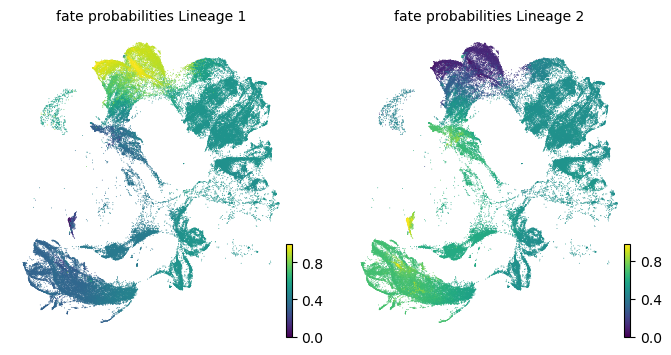

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_Harmony_fate_probability2_Neurogenesis_nn100_npc50.png


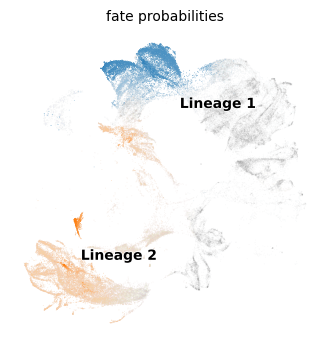

In [31]:
g.compute_fate_probabilities(preconditioner='ilu',tol=1e-15)
g.plot_fate_probabilities(same_plot=False,  basis = basis, save = f'Harmony_fate_probability1_{region}_nn{n_neighbors}_npc{n_pcs}.png')
g.plot_fate_probabilities(basis = basis, save = f'Harmony_fate_probability2_{region}_nn{n_neighbors}_npc{n_pcs}.png')


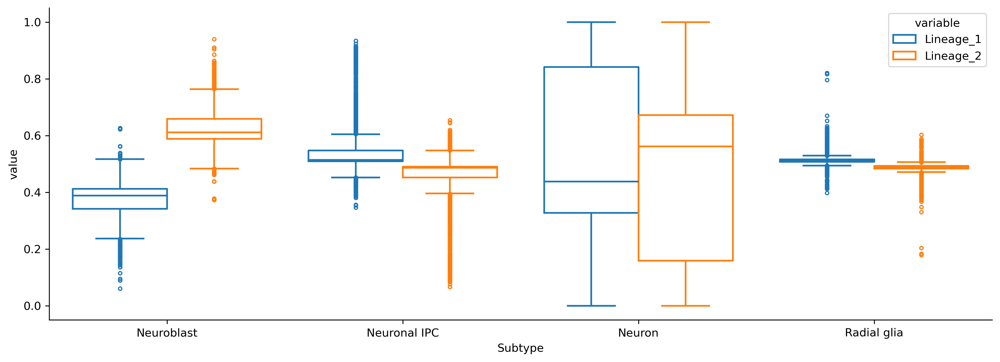

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lineage_memberships = pd.DataFrame(g.fate_probabilities,
                                   index= adata_Forebrain.obs_names,
                                   columns =g.terminal_states.cat.categories) 

df = lineage_memberships.melt()
df = df.assign(membership=np.tile(lineage_memberships.idxmax(axis=1).values,2))
df = df.assign(Subtype=np.tile(adata_Forebrain.obs['class'],2))
plt.figure(figsize=(15,5),dpi=300)
sns.boxplot(data = df, x='Subtype',y='value',hue='variable', fill=False,flierprops={"marker": "."},)
# plt.show()
plt.savefig(f'lineage_membership_prob_{region}_{n_neighbors}.png')

In [33]:
lineage_memberships['membership'] = lineage_memberships.idxmax(axis=1)

In [34]:
lineage_memberships['membership']

10X89_1:AACCATGTCGATGAGG     Lineage_2
10X89_1:AACTCCCGTAGATTAG     Lineage_2
10X89_1:AACTCCCGTCTCTTTA     Lineage_2
10X89_1:AAGGCAGGTTCGCGAC     Lineage_2
10X89_1:AAGTCTGCATGACGGA     Lineage_2
                               ...    
10X115_6:GAGGTGAGTAGTGAAT    Lineage_1
10X115_6:GGGTCTGTCACGCGGT    Lineage_2
10X115_6:GTTAAGCCAAAGCGGT    Lineage_1
10X115_6:TGGCGCAAGAGCCTAG    Lineage_1
10X115_6:GGGAGATCAGACAGGT    Lineage_1
Name: membership, Length: 75180, dtype: object

In [35]:
adata_Forebrain_L1 = adata_Forebrain[(lineage_memberships.membership == 'Lineage_1')]
adata_Forebrain_L1.obs['class'].value_counts()

class
Radial glia     21765
Neuron          13410
Neuronal IPC     7632
Neuroblast         57
Name: count, dtype: int64

In [36]:
adata_Forebrain_L2 = adata_Forebrain[(lineage_memberships.membership == 'Lineage_2')]
adata_Forebrain_L2.obs['class'].value_counts()

class
Neuron          15155
Neuroblast      11934
Radial glia      4234
Neuronal IPC      993
Name: count, dtype: int64

In [ ]:
# del adata_Forebrain

In [55]:
def subsample_and_analyze(data, n_pcs, n_neighbors, cell_idx, n_iterations=4):
    results = []
    for i in range(n_iterations):
        adata_sub = data.copy()
        print((cell_idx).shape)
        sc.pp.neighbors(adata_sub, n_pcs=n_pcs, n_neighbors=n_neighbors, use_rep='X_harmony', random_state=i)
        early_cell = adata_sub.obs_names[cell_idx[i]]
        print(early_cell)

        palantir.plot.highlight_cells_on_umap(adata_sub, [early_cell], embedding_basis='X_umap_all')
        plt.show()
        
        sce.tl.palantir(adata_sub, n_components=n_pcs, use_adjacency_matrix=True)    
        pr_res = sce.tl.palantir_results(
            adata_sub,
            early_cell=early_cell,
            ms_data='X_palantir_multiscale',
        )
        print(pr_res.pseudotime.values)
        results.append({f'subsample_{i}': pr_res.pseudotime.values.copy()})

        print("Done")
    
    return results

In [41]:
adata_Forebrain_L1.obsm

AxisArrays with keys: X_PCA_for_Harmony, X_UMAP_RNA_Harmony, X_UMAP_RNA_Harmony_3D, X_harmony, X_palantir_diff_comp, X_palantir_multiscale, X_umap, T_fwd_UMAP_RNA_Harmony, T_fwd_umap, schur_vectors_fwd, macrostates_fwd_memberships, lineages_fwd

# Forebrain_L1

In [ ]:
n_pcs=50
n_neighbors=100
# sc.pp.highly_variable_genes(adata_ExN,n_top_genes=5000, batch_key='Sample_ID')
# sc.tl.pca(adata_ExN, n_comps=n_pcs)
# sce.pp.harmony_integrate(adata_ExN, 'Sample_ID', max_iter_harmony=100)
sc.pp.neighbors(adata_Forebrain_L1,use_rep='X_harmony', n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=42)
adata_Forebrain_L1.obsm['X_umap_all'] = adata_Forebrain_L1.obsm['X_UMAP_RNA_Harmony']
sc.tl.umap(adata_Forebrain_L1)

(1448,)
10X178_1:GTTAGACAGACGGTTG


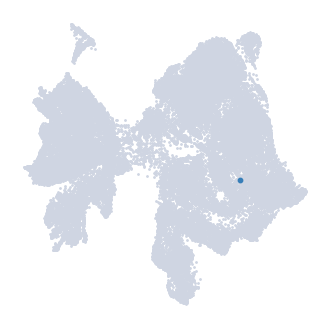

In [49]:
condition = np.where((adata_Forebrain_L1.obs['class']=='Radial glia')&
                     (adata_Forebrain_L1.obs['Age']==np.min(adata_Forebrain_L1.obs['Age']))#&
                    #  (adata_ExN.obsm['X_umap'][:,0]>np.quantile(adata_ExN.obsm['X_umap'][:,0],0.95))#&
                     # (adata_ExN.obsm['X_umap'][:,1]<np.quantile(adata_ExN.obsm['X_umap'][:,1],0.05))
                    )
print(condition[0].shape)

start_cell = adata_Forebrain_L1.obs_names[condition[0][-10]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata_Forebrain_L1, [start_cell])
plt.show()

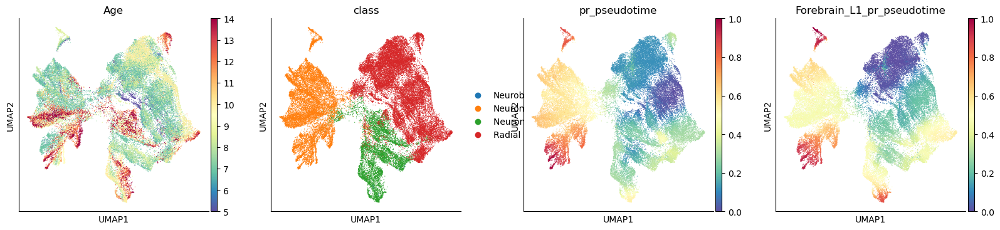

In [ ]:
sce.tl.palantir(adata_Forebrain_L1, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Forebrain_L1,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
print(pr_res.pseudotime)
adata_Forebrain_L1.obs['Forebrain_L1_pr_pseudotime']=pr_res.pseudotime

sc.pl.embedding(adata_Forebrain_L1, basis="umap", 
                color=['Age', 'class','pr_pseudotime', 'Forebrain_L1_pr_pseudotime',],)

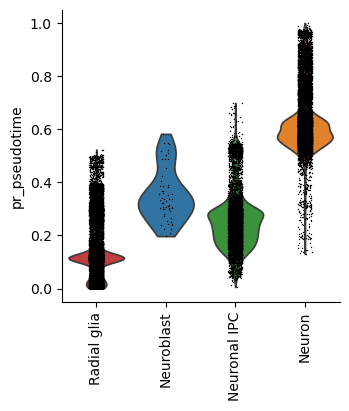

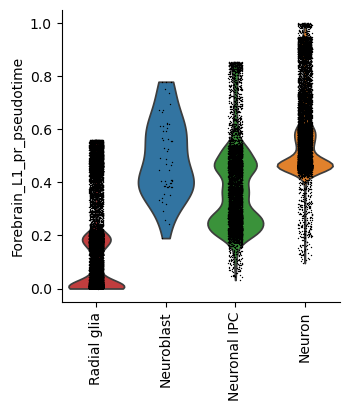

In [53]:
trajectory = ["Radial glia", "Neuroblast","Neuronal IPC",'Neuron']
# plot the Monocyte trajectory
mask = np.in1d(adata_Forebrain_L1.obs["class"], trajectory)
sc.pl.violin(
    adata_Forebrain_L1[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
)
sc.pl.violin(
    adata_Forebrain_L1[mask],
    keys=["Forebrain_L1_pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
    save=f'_{region}_Forebrain_L1_pr_pseudotime_v3_05282026.png'
)

(1448,)
10X177_4:AAACCCATCGCTCTCA


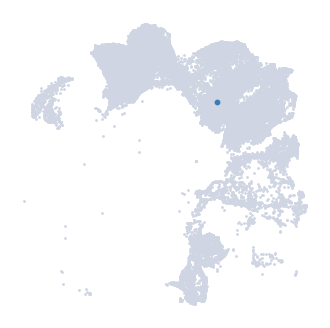

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.04355358680089315 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5835084358851115 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.67143101 0.61671797 0.56438253 ... 0.3545248  0.11129908 0.13501582]
Done
(1448,)
10X177_4:AACAAAGCAGCAGGAT


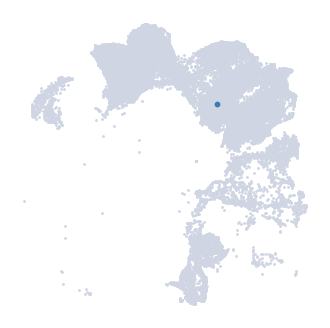

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.04438863197962443 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.586368219057719 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.67142697 0.61670248 0.55599184 ... 0.35571294 0.11051673 0.13611293]
Done
(1448,)
10X177_4:AAGACAAAGGATTCAA


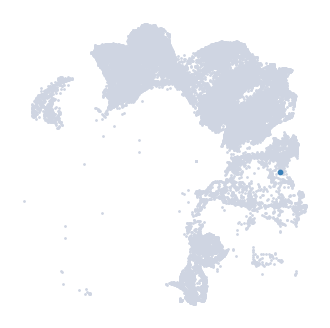

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.044216716289520265 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.701973028977712 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.58894631 0.5415746  0.44421143 ... 0.28405979 0.07927166 0.06100369]
Done
(1448,)
10X177_4:AAGACAACAGACCAGA


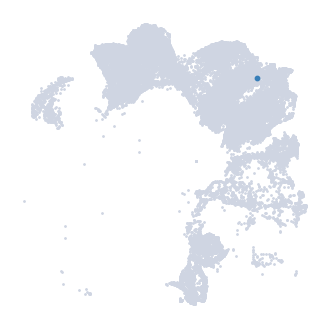

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.044120534261067705 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5722969849904378 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.43196082 0.42707862 0.45444624 ... 0.25292579 0.39269383 0.39235423]
Done


In [56]:
ExN_results = subsample_and_analyze(adata_Forebrain_L1, n_pcs=n_pcs, n_neighbors=n_neighbors, cell_idx=condition[0])
df = pd.DataFrame({
    key: pd.Series(value) for subsample in ExN_results for key, value in subsample.items()})
df.index = adata_Forebrain_L1.obs_names.values
df['pr_pseudotime'] = adata_Forebrain_L1.obs['pr_pseudotime']
df['Forebrain_L1_pr_pseudotime'] = adata_Forebrain_L1.obs['Forebrain_L1_pr_pseudotime']
df.to_csv(f'Harmony_pr_pseudotime_rep4_{region}_Forebrain_L1_v3_05282026.csv')

In [57]:
adata_Forebrain_L1.obs['subsample_0'] = df['subsample_0']
adata_Forebrain_L1.obs['subsample_1'] = df['subsample_1']
adata_Forebrain_L1.obs['subsample_2'] = df['subsample_2']
adata_Forebrain_L1.obs['subsample_3'] = df['subsample_3']

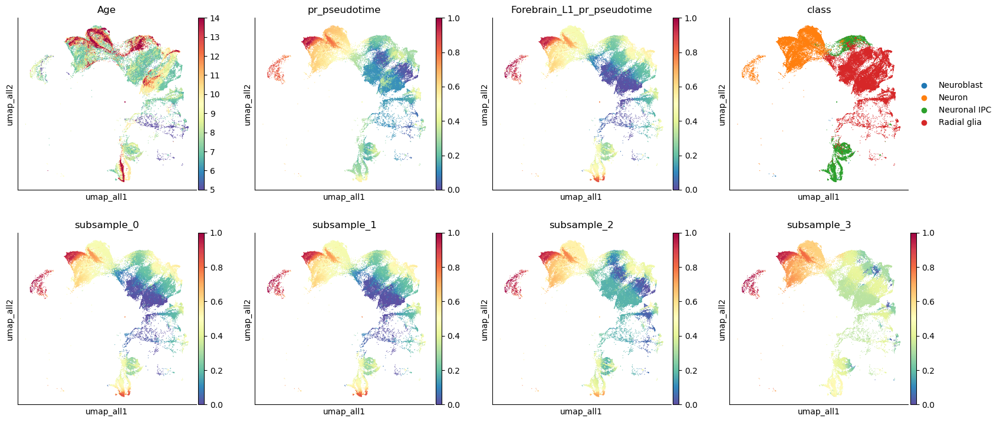

In [ ]:
adata_Forebrain_L1.obs['subsample_0'] = df['subsample_0']
adata_Forebrain_L1.obs['subsample_1'] = df['subsample_1']
adata_Forebrain_L1.obs['subsample_2'] = df['subsample_2']
adata_Forebrain_L1.obs['subsample_3'] = df['subsample_3']

sc.pl.embedding(adata_Forebrain_L1, basis="umap_all", 
                color=['Age', 'pr_pseudotime', 'Forebrain_L1_pr_pseudotime', 'class',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Forebrain_L1_v3_05282026.png')

Processing column: subsample_0
Processing column: subsample_1
Processing column: subsample_2
Processing column: subsample_3
Processing column: pr_pseudotime
Processing column: Forebrain_L1_pr_pseudotime


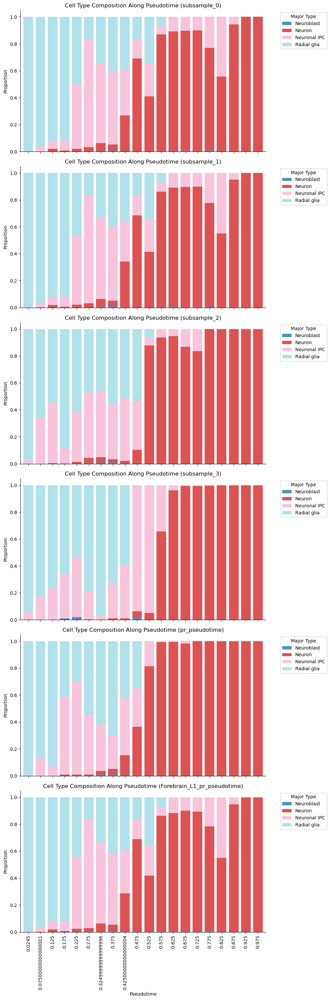

In [59]:
num_bins=20

num_cols = len(df.columns)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols), sharex=True)

# If there's only one column, adjust for 1D array issue
if num_cols == 1:
    axes = [axes]

# Iterate through each column in df and generate composition plots in subplots
for idx, col in enumerate(df.columns):
    print(f"Processing column: {col}")

    # Create pseudotime bins
    adata_Forebrain_L1.obs['pseudotime_bin'] = pd.cut(df[col], bins=num_bins)

    # Compute composition
    composition = (
        adata_Forebrain_L1.obs.groupby(['pseudotime_bin', 'class'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)  # Normalize to proportions
    )

    # Convert bin intervals to bin centers
    bin_centers = [interval.mid for interval in composition.index.categories]
    composition.index = bin_centers[:len(composition)]  # Ensure alignment

    # Plot composition in the respective subplot
    composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8, ax=axes[idx])
    axes[idx].set_title(f'Cell Type Composition Along Pseudotime ({col})')
    axes[idx].set_xlabel('Pseudotime')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    # axes[idx].grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
fig.savefig(f'../figures_logCPM/{region}/{region}_Forebrain_L1_composition_v3_05282026.png')

In [60]:
del adata_Forebrain_L1

# Forebrain_L2

In [61]:
n_pcs=50
n_neighbors=100
# sc.pp.highly_variable_genes(adata_ExN,n_top_genes=5000, batch_key='Sample_ID')
# sc.tl.pca(adata_ExN, n_comps=n_pcs)
# sce.pp.harmony_integrate(adata_ExN, 'Sample_ID', max_iter_harmony=100)
sc.pp.neighbors(adata_Forebrain_L2,use_rep='X_harmony', n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=42)
adata_Forebrain_L2.obsm['X_umap_all'] = adata_Forebrain_L2.obsm['X_UMAP_RNA_Harmony']
sc.tl.umap(adata_Forebrain_L2)

(208,)
10X178_1:GATAGAAGTTCAATCG


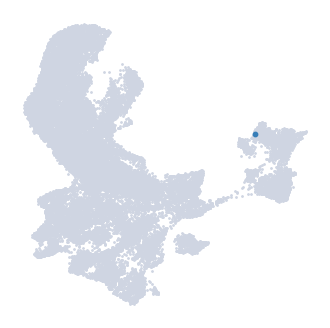

In [62]:
condition = np.where((adata_Forebrain_L2.obs['class']=='Radial glia')&
                     (adata_Forebrain_L2.obs['Age']==np.min(adata_Forebrain_L2.obs['Age']))#&
                    #  (adata_ExN.obsm['X_umap'][:,0]>np.quantile(adata_ExN.obsm['X_umap'][:,0],0.95))#&
                     # (adata_ExN.obsm['X_umap'][:,1]<np.quantile(adata_ExN.obsm['X_umap'][:,1],0.05))
                    )
print(condition[0].shape)

start_cell = adata_Forebrain_L2.obs_names[condition[0][-10]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata_Forebrain_L2, [start_cell])
plt.show()

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.022456165154774985 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5106319665908814 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9995
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
10X89_1:AACCATGTCGATGAGG     0.613550
10X89_1:AACTCCCGTAGATTAG     0.642019
10X89_1:AACTCCCGTCTCTTTA     0.661976
10X89_1:AAGGCAGGTTCGCGAC     0.654495
10X89_1:AAGTCTGCATGACGGA     0.704622
                               ...   
10X115_6:GCAATCATCCTTTACA    0.606132
10X115_6:TGGGAAGCAAATCCGT    0.597141
10X115_6:ACTGTCCGTGTTCGAT    0.221059
10X115_6:GAGCAGATCATCGGAT    0.045971
10X115_6:GGGTCTGTCACGCGGT    0.231292
Length: 32316, dtype: float64


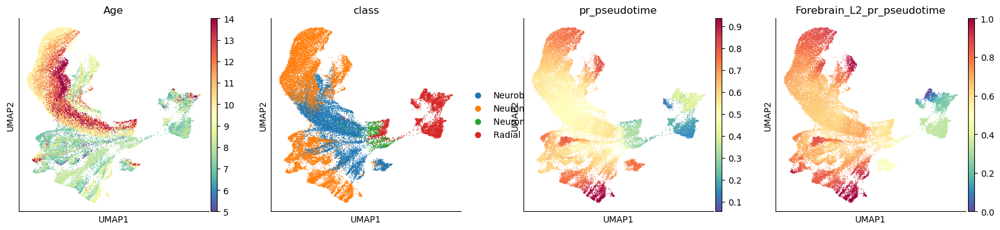

In [63]:
sce.tl.palantir(adata_Forebrain_L2, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Forebrain_L2,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
print(pr_res.pseudotime)
adata_Forebrain_L2.obs['Forebrain_L2_pr_pseudotime']=pr_res.pseudotime

sc.pl.embedding(adata_Forebrain_L2, basis="umap", 
                color=['Age', 'class','pr_pseudotime', 'Forebrain_L2_pr_pseudotime',],)

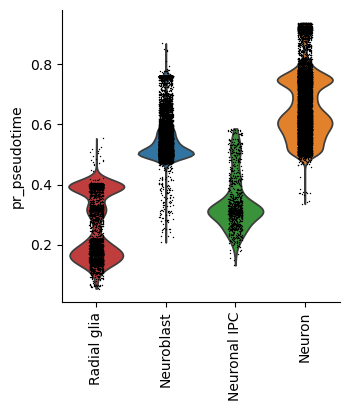

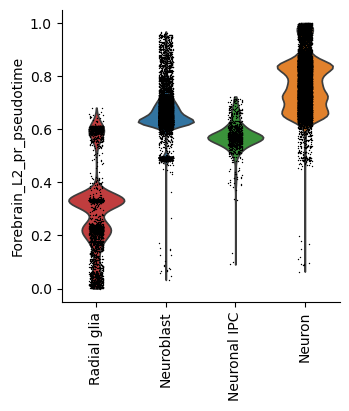

In [64]:
trajectory = ["Radial glia", "Neuroblast","Neuronal IPC",'Neuron']
# plot the Monocyte trajectory
mask = np.in1d(adata_Forebrain_L2.obs["class"], trajectory)
sc.pl.violin(
    adata_Forebrain_L2[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
)
sc.pl.violin(
    adata_Forebrain_L2[mask],
    keys=["Forebrain_L2_pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
    save=f'_{region}_Forebrain_L2_pr_pseudotime_v3_05282026.png'
)

(208,)
10X177_4:AGATCCACAGCACGAA


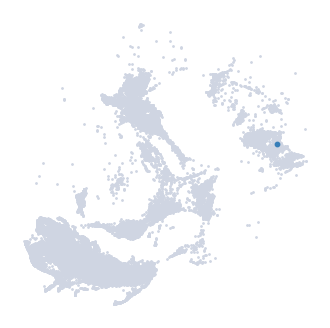

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.02309623161951701 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6044884999593099 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.604495   0.63148888 0.64947105 ... 0.02232886 0.18923468 0.00103305]
Done
(208,)
10X177_4:ATTCATCGTCCCGGTA


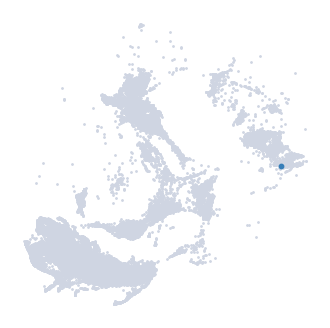

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.024008282025655112 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5184028784434 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.60561412 0.62682852 0.65309055 ... 0.02279249 0.18198094 0.01013411]
Done
(208,)
10X177_4:ATTCCATGTCCCGGTA


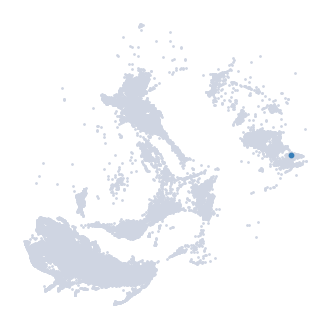

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.02290949821472168 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5924702167510987 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9995
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.60602886 0.63940826 0.65882599 ... 0.21112302 0.03400919 0.22153228]
Done
(208,)
10X177_4:ATTCCTACAATCGCGC


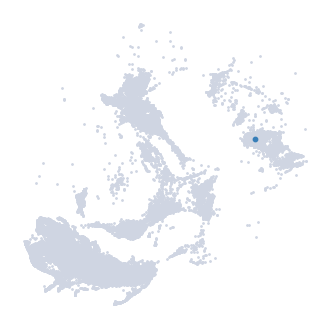

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.022582268714904784 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6074926495552063 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9995
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.46086555 0.498162   0.54219941 ... 0.25713919 0.35805883 0.27955483]
Done


In [65]:
L2_results = subsample_and_analyze(adata_Forebrain_L2, n_pcs=n_pcs, n_neighbors=n_neighbors, cell_idx=condition[0])
df = pd.DataFrame({
    key: pd.Series(value) for subsample in L2_results for key, value in subsample.items()})
df.index = adata_Forebrain_L2.obs_names.values
df['pr_pseudotime'] = adata_Forebrain_L2.obs['pr_pseudotime']
df['Forebrain_L2_pr_pseudotime'] = adata_Forebrain_L2.obs['Forebrain_L2_pr_pseudotime']
df.to_csv(f'Harmony_pr_pseudotime_rep4_{region}_Forebrain_L2_v3_05282026.csv')

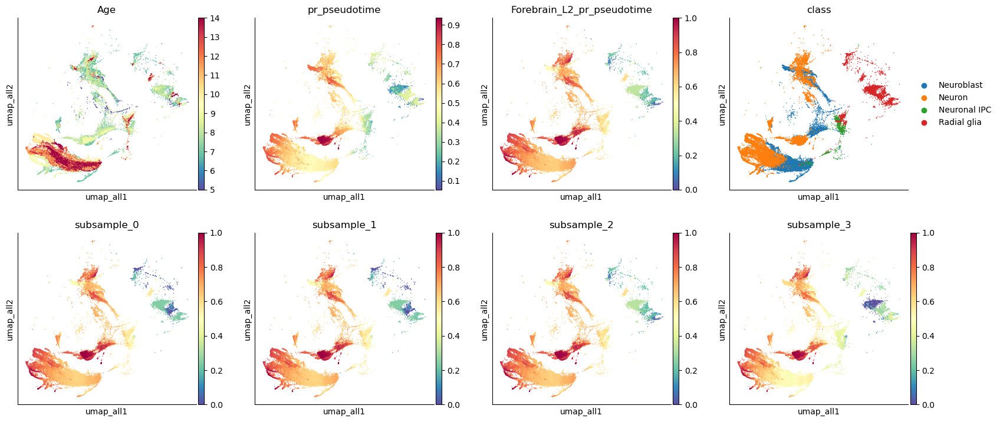

In [66]:
adata_Forebrain_L2.obs['subsample_0'] = df['subsample_0']
adata_Forebrain_L2.obs['subsample_1'] = df['subsample_1']
adata_Forebrain_L2.obs['subsample_2'] = df['subsample_2']
adata_Forebrain_L2.obs['subsample_3'] = df['subsample_3']

sc.pl.embedding(adata_Forebrain_L2, basis="umap_all", 
                color=['Age', 'pr_pseudotime', 'Forebrain_L2_pr_pseudotime', 'class',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Forebrain_L2_v3_05282026.png')

Processing column: subsample_0
Processing column: subsample_1
Processing column: subsample_2
Processing column: subsample_3
Processing column: pr_pseudotime
Processing column: Forebrain_L2_pr_pseudotime


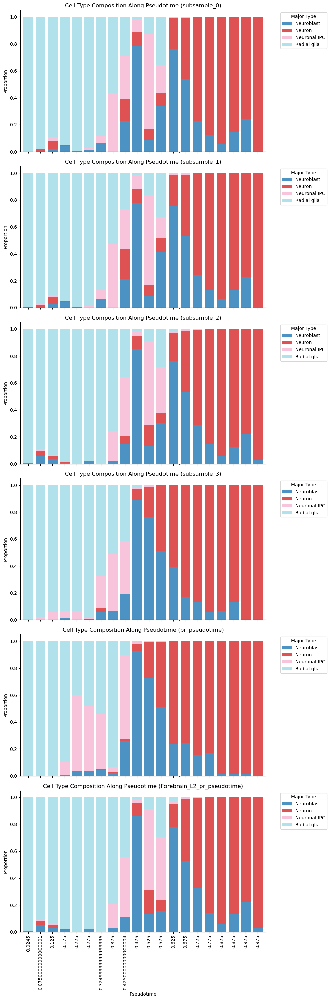

In [67]:
num_bins=20

num_cols = len(df.columns)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols), sharex=True)

# If there's only one column, adjust for 1D array issue
if num_cols == 1:
    axes = [axes]

# Iterate through each column in df and generate composition plots in subplots
for idx, col in enumerate(df.columns):
    print(f"Processing column: {col}")

    # Create pseudotime bins
    adata_Forebrain_L2.obs['pseudotime_bin'] = pd.cut(df[col], bins=num_bins)

    # Compute composition
    composition = (
        adata_Forebrain_L2.obs.groupby(['pseudotime_bin', 'class'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)  # Normalize to proportions
    )

    # Convert bin intervals to bin centers
    bin_centers = [interval.mid for interval in composition.index.categories]
    composition.index = bin_centers[:len(composition)]  # Ensure alignment

    # Plot composition in the respective subplot
    composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8, ax=axes[idx])
    axes[idx].set_title(f'Cell Type Composition Along Pseudotime ({col})')
    axes[idx].set_xlabel('Pseudotime')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    # axes[idx].grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
fig.savefig(f'../figures_logCPM/{region}/{region}_Forebrain_L2_composition_v3_05282026.png')

## pseudotime repetition

(15,)
10X177_4:GAGTTACCAAGTAGTA


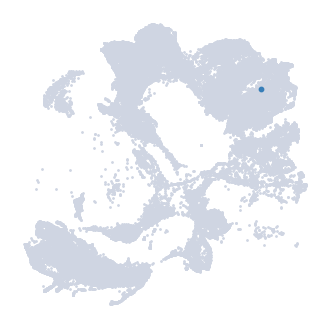

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.04918288389841716 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.243974749247233 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9993
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.48949622 0.49655132 0.53290254 ... 0.48515005 0.05201794 0.04051187]
Done
(15,)
10X177_4:GCCAACGCAATGTCTG


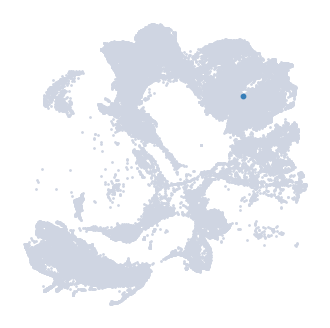

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.050839567184448244 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.1729643980662028 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9993
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.48760604 0.49613045 0.53101248 ... 0.48390362 0.05223948 0.04118673]
Done
(15,)
10X177_4:TTGGATGCAGACGCTC


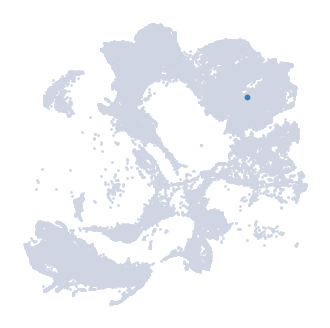

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.05015435218811035 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Time for shortest paths: 1.1126354535420735 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9994
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.48868526 0.5007075  0.53679072 ... 0.48432241 0.05219489 0.04043028]
Done
(15,)
10X177_5:ACTCCCAGTGTACGCC


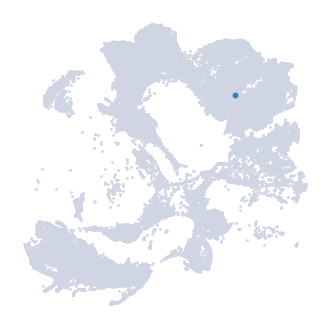

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.05050035317738851 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Time for shortest paths: 1.1709574143091837 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9994
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.48695171 0.49788049 0.53359915 ... 0.48638355 0.05283248 0.04116062]
Done
                          subsample_0  subsample_1  subsample_2  subsample_3
10X89_1:AACCATGTCGATGAGG     0.489496     0.487606     0.488685     0.486952
10X89_1:AACTCCCGTAGATTAG     0.496551     0.496130     0.500707     0.497880
10X89_1:AACTCCCGTCTCTTTA     0.532903     0.531012     0.536791     0.533599
10X89_1:AAGGCAGGTTCGCGAC     0.513719     0.511916     0.512248     0.514877
10X89_1:AAGTCTGCATGACGGA     0.573127     0.572341     0.573724     0.572858


In [ ]:
Forebrain_results = subsample_and_analyze(adata_Forebrain, n_pcs=n_pcs, n_neighbors=n_neighbors, cell_idx=condition)

df = pd.DataFrame({
    key: pd.Series(value.copy())  # Ensure deep copy
    for subsample in Forebrain_results
    for key, value in subsample.items()
})

df.index = adata_Forebrain.obs_names.values
print(df.head())

df['pr_pseudotime'] = adata_Forebrain.obs['pr_pseudotime'].copy()
df.to_csv(f'Harmony_pr_psueotime_rep4_{region}_Forebrain_v3_05282026.csv')

for i in range(4):
    adata_Forebrain.obs[f'subsample_{i}'] = df[f'subsample_{i}'].copy()

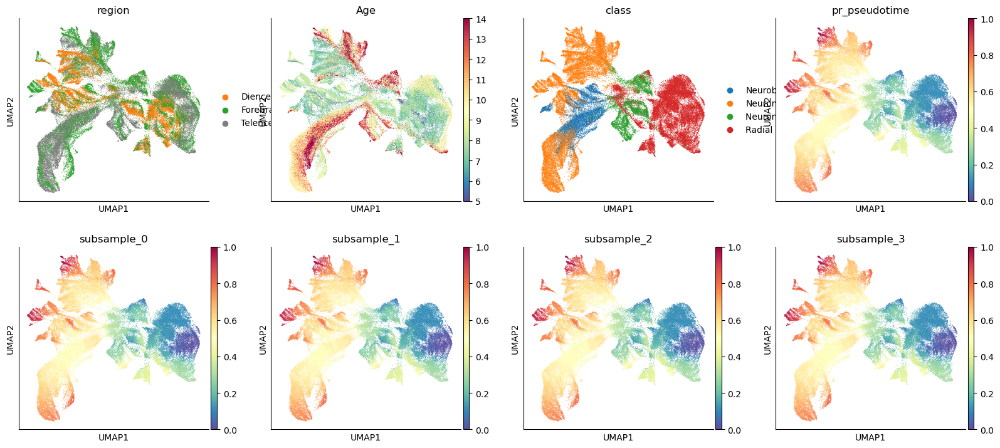

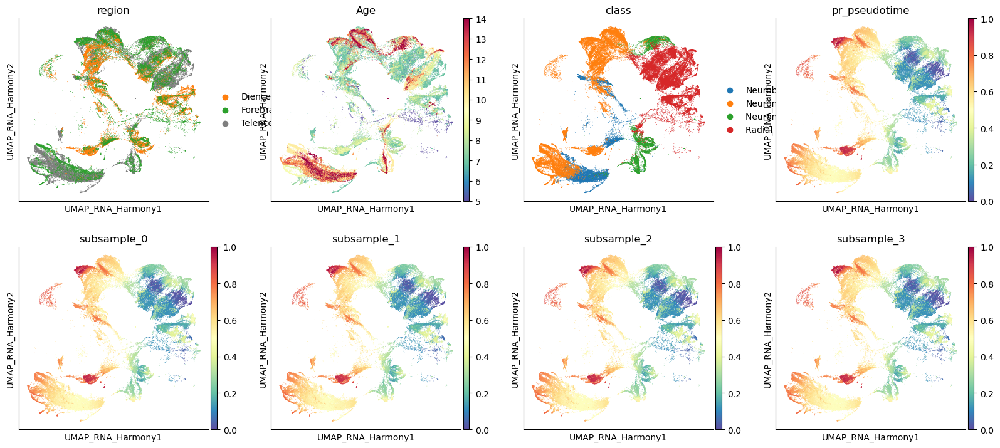

In [ ]:
sc.pl.embedding(adata_Forebrain, basis="umap", 
                color=['region', 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Forebrain_v3_05282026.png')
sc.pl.embedding(adata_Forebrain, basis="UMAP_RNA_Harmony", 
                color=['region', 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Forebrain_v3_05282026.png')

Processing column: subsample_0
Processing column: subsample_1
Processing column: subsample_2
Processing column: subsample_3
Processing column: pr_pseudotime


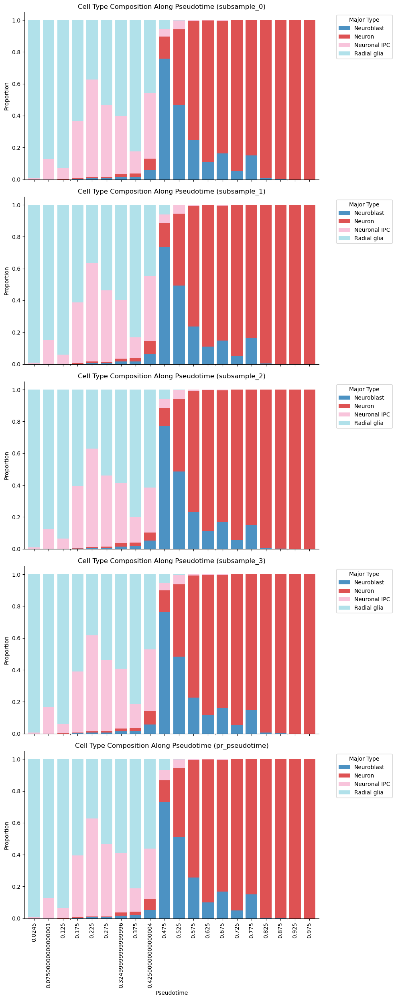

In [ ]:
num_bins=20

num_cols = len(df.columns)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols), sharex=True)

# If there's only one column, adjust for 1D array issue
if num_cols == 1:
    axes = [axes]

# Iterate through each column in df and generate composition plots in subplots
for idx, col in enumerate(df.columns):
    print(f"Processing column: {col}")

    # Create pseudotime bins
    adata_Forebrain.obs['pseudotime_bin'] = pd.cut(df[col], bins=num_bins)

    # Compute composition
    composition = (
        adata_Forebrain.obs.groupby(['pseudotime_bin', 'class'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)  # Normalize to proportions
    )

    # Convert bin intervals to bin centers
    bin_centers = [interval.mid for interval in composition.index.categories]
    composition.index = bin_centers[:len(composition)]  # Ensure alignment

    # Plot composition in the respective subplot
    composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8, ax=axes[idx])
    axes[idx].set_title(f'Cell Type Composition Along Pseudotime ({col})')
    axes[idx].set_xlabel('Pseudotime')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    # axes[idx].grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/05282026/{region}_Forebrain_composition_v3_05282026.png')

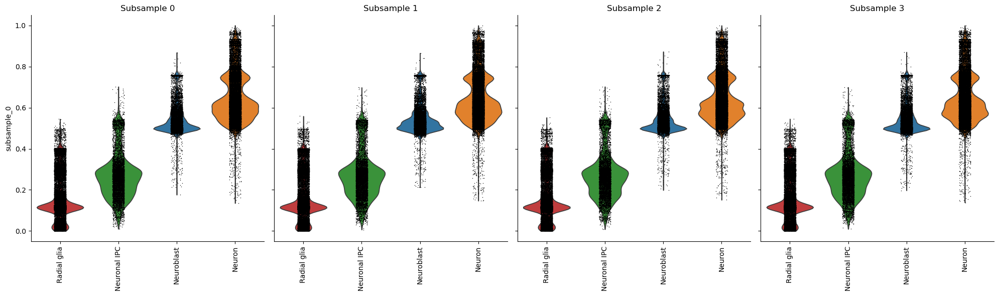

In [ ]:
# for i in range(4):
#     sc.pl.violin(
#         adata_Forebrain[mask],
#         keys=[f"subsample_{i}"],
#         groupby="class",
#         rotation=90,
#         order=trajectory,
#         save=f"_{region}_Forebrain_rep{i}_v3_01272025.png"
#     )

# Define number of violin plots
num_subsamples = 4
fig, axes = plt.subplots(nrows=1, ncols=num_subsamples, figsize=(5 * num_subsamples, 6), sharey=True)
for i in range(num_subsamples):
    ax = axes[i] if num_subsamples > 1 else axes  
    sc.pl.violin(
        adata_Forebrain[mask],
        keys=[f"subsample_{i}"],
        groupby="class",
        rotation=90,
        order=trajectory,
        show=False,
        ax=ax  
    )

    ax.set_title(f"Subsample {i}")
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/05282026/{region}_Forebrain_violin_subsample_pt_v3_05282026.png')

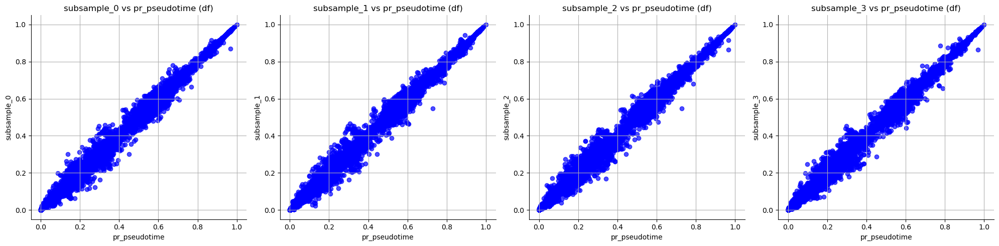

In [ ]:
import matplotlib.pyplot as plt

num_cols = len(df.columns) - 1
fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(5 * num_cols, 5), sharex=True, sharey=False)
if num_cols == 1:
    axes = [axes]
col_index = 0 
for col in df.columns:
    if col != "pr_pseudotime":
        axes[col_index].scatter(df["pr_pseudotime"], df[col], color='blue', alpha=0.7)
        axes[col_index].set_title(f"{col} vs pr_pseudotime (df)")
        axes[col_index].set_xlabel("pr_pseudotime")
        axes[col_index].set_ylabel(col)
        axes[col_index].grid(True)

        col_index += 1
plt.tight_layout()
plt.show()

filename = f'./figures_logCPM/{region}/05282026/{region}_Forebrain_comparison_w_lineage_specific_pt_v3_05282026.png'
fig.savefig(filename, dpi=300, bbox_inches='tight')


In [43]:
# del adata_Forebrain

# Hindbrain

In [24]:
adata_Hindbrain = adata[adata.obs['mainRegion'] == 'Hindbrain'].copy()
# adata_Hindbrain.write_h5ad('Hindbrain.h5ad')
# del adata_Hindbrain

In [25]:
sc.pp.neighbors(adata_Hindbrain,use_rep='X_harmony', n_neighbors = n_neighbors, n_pcs=n_pcs,  random_state=42)
# adata_Hindbrain.obsm['X_umap_all']=adata_Hindbrain.obsm['X_umap']
sc.tl.umap(adata_Hindbrain)

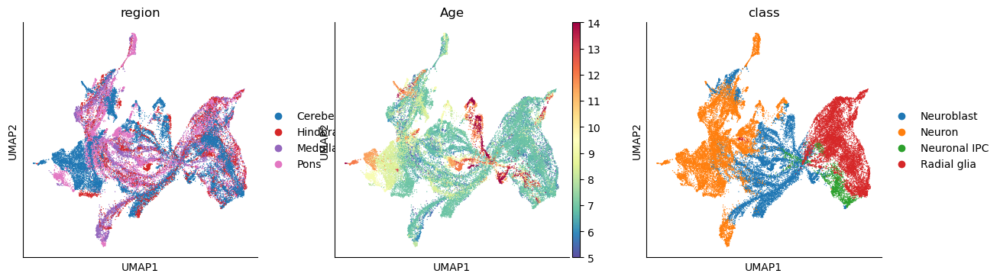

In [26]:
sc.pl.embedding(adata_Hindbrain, basis="umap", 
                color=['region', 'Age', 'class'], )

10X179_4:TCCTGCATCAGACCCG


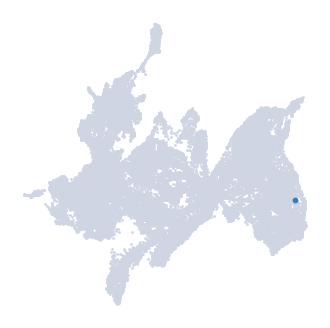

In [27]:
q0 = np.quantile(adata_Hindbrain.obsm['X_umap'][:,0],0.95)
q1 = np.quantile(adata_Hindbrain.obsm['X_umap'][:,1],0.75)
start_cell = adata_Hindbrain.obs_names[np.where((adata_Hindbrain.obs['class']=='Radial glia')&
                                                (adata_Hindbrain.obs['Age']==np.min(adata_Hindbrain.obs['Age']))#&
                                                # (adata_Hindbrain.obsm['X_umap'][:,0]>q0)&
                                                # (adata_Hindbrain.obsm['X_umap'][:,1]>q1)
                                               )[0][-1]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata_Hindbrain, [start_cell])
plt.show()

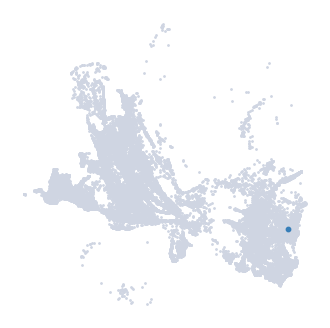

In [28]:
palantir.plot.highlight_cells_on_umap(adata_Hindbrain, [start_cell],embedding_basis='X_UMAP_RNA_Harmony')
plt.show()

In [29]:
sce.tl.palantir(adata_Hindbrain, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Hindbrain,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
print(pr_res.pseudotime)
adata_Hindbrain.obs['pr_pseudotime']=pr_res.pseudotime

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.020631547768910727 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5289839188257853 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9987
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
10X109_7:AGAATAGGTCTAACGT    0.602417
10X109_7:AGTGTCAAGGAGCGAG    0.739894
10X109_7:ATAGACCCAAAGAATC    0.678588
10X109_7:CAACCAATCAGTTTGG    0.644716
10X109_7:CAGGTGCCAGGGATTG    0.535562
                               ...   
10X254_3:CAGATTGTCAGTCAGT    0.176905
10X254_3:CATAAGCGTTTGCAGT    0.446130
10X254_3:CCGATGGTCCTGGGAC    0.251668
10X254_3:GGTAACTCAATACGAA    0.406650
10X254_3:TATCCTACAGCTACAT    0.305036
Length: 35968, dtype: float64


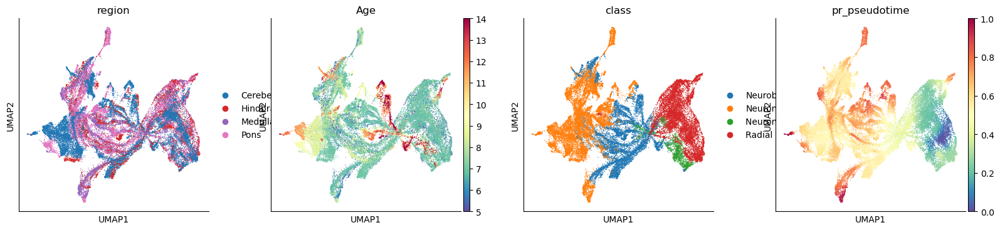

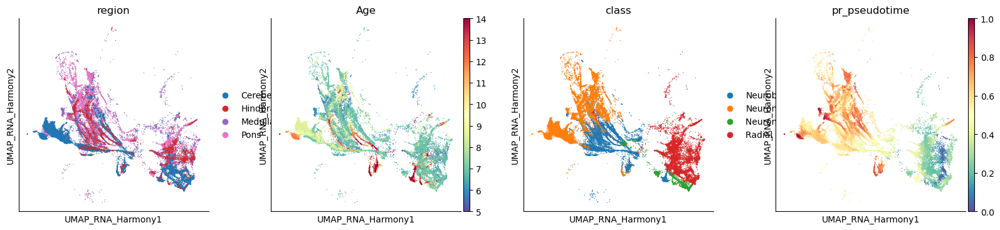

In [30]:
sc.pl.embedding(adata_Hindbrain, basis="umap", 
                color=['region', 'Age', 'class','pr_pseudotime'], )
sc.pl.embedding(adata_Hindbrain, basis="UMAP_RNA_Harmony", 
                color=['region', 'Age', 'class','pr_pseudotime'], )

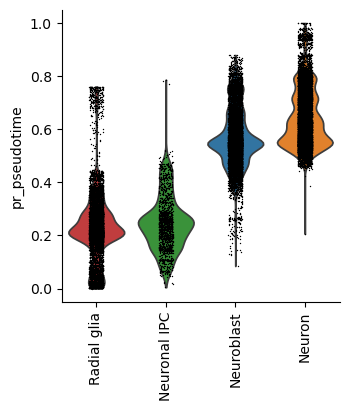

In [ ]:
trajectory = ['Radial glia', 'Neuronal IPC','Neuroblast','Neuron']
# plot the Monocyte trajectory
mask = np.in1d(adata_Hindbrain.obs["class"], trajectory)
sc.pl.violin(
    adata_Hindbrain[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
    save=f"_{region}_Hindbrain_v3_05282026.png"
)

<Figure size 1000x300 with 0 Axes>

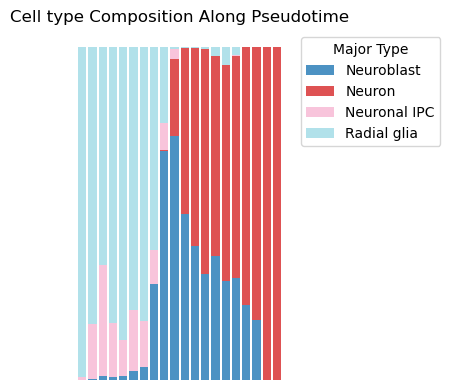

In [32]:
num_bins = 20
adata_Hindbrain.obs['pseudotime_bin'] = pd.cut(adata_Hindbrain.obs['pr_pseudotime'], bins=num_bins)
composition = (
    adata_Hindbrain.obs.groupby(['pseudotime_bin', 'class'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x/x.sum(), axis=1)  # Normalize to proportions
)
bin_centers = [interval.mid for interval in composition.index.categories]
composition.index = bin_centers[:len(composition)]  # Ensure alignment


plt.figure(figsize=(10, 3))
composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8)
plt.title('Cell type Composition Along Pseudotime')
plt.axis("off")
plt.xlabel('Pseudotime')
plt.ylabel('Proportion')
plt.legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
condition = np.where((adata_Hindbrain.obs['Age']==np.min(adata_Hindbrain.obs['Age']))&
                     (adata_Hindbrain.obs['class']=='Radial glia')#&
                     # (adata_Hindbrain.obsm['X_umap'][:,0]>q0)&
                     # (adata_Hindbrain.obsm['X_umap'][:,1]>q1)
                    )
condition[0].shape

(820,)

(820,)
10X178_2:AGGACGATCTCGTGGG


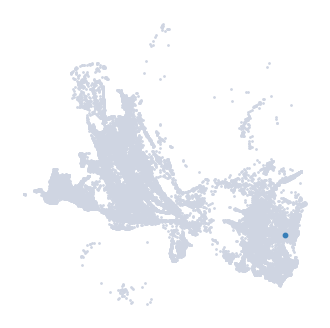

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.020653684933980305 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5278578797976176 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9985
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.60367618 0.74079521 0.67919933 ... 0.28058116 0.40661407 0.31099249]
Done
(820,)
10X178_2:CATGCAATCACATTGG


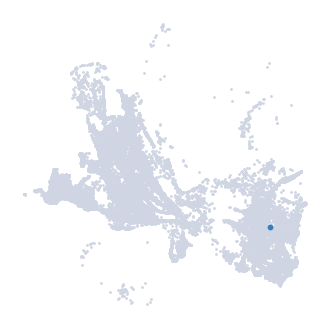

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.02067833344141642 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5255789796511332 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9986
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.60372463 0.74030758 0.68564204 ... 0.28069759 0.40685106 0.30513555]
Done
(820,)
10X178_2:GACCCTTTCGCATTAG


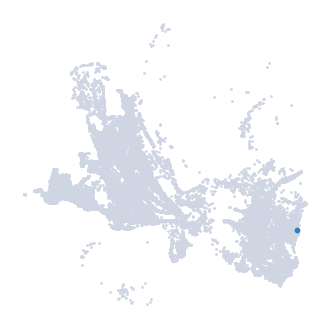

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.02050846815109253 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5169294675191244 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9988
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.6591541  0.76800547 0.72366672 ... 0.39199471 0.48263941 0.42068959]
Done
(820,)
10X178_2:TCAGCAATCGTAGTCA


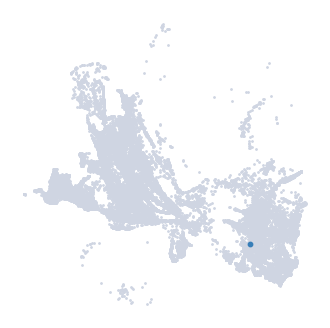

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.02139049768447876 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6422595500946044 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9985
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.53017057 0.7247448  0.58343536 ... 0.13307014 0.27682759 0.20060336]
Done


In [ ]:
Hindbrain_results = subsample_and_analyze(adata_Hindbrain, n_pcs=n_pcs, n_neighbors=n_neighbors, cell_idx=condition[0])
df = pd.DataFrame({
    key: pd.Series(value) for subsample in Hindbrain_results for key, value in subsample.items()})
df.index = adata_Hindbrain.obs_names.values
df['pr_pseudotime'] = adata_Hindbrain.obs['pr_pseudotime']
df.to_csv(f'Harmony_pr_pseudotime_rep4_{region}_Hindbrain_v3_05282026.csv')

In [35]:
adata_Hindbrain.obs['subsample_0'] = df['subsample_0']
adata_Hindbrain.obs['subsample_1'] = df['subsample_1']
adata_Hindbrain.obs['subsample_2'] = df['subsample_2']
adata_Hindbrain.obs['subsample_3'] = df['subsample_3']

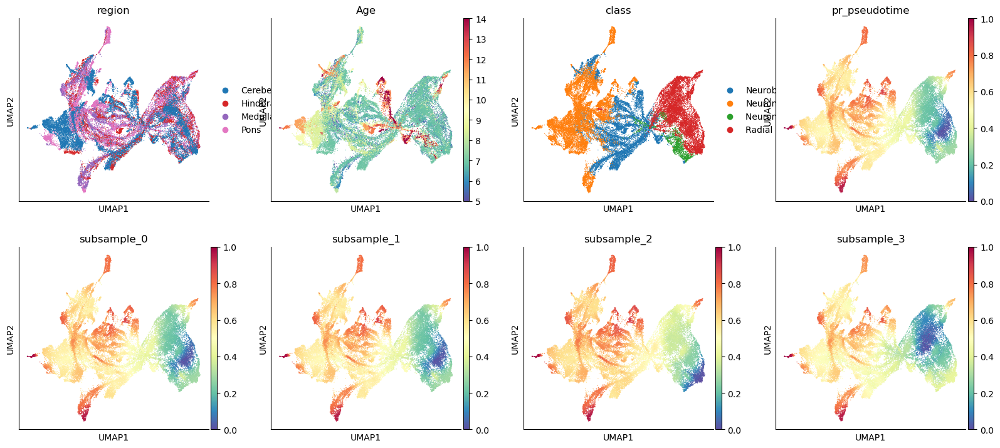

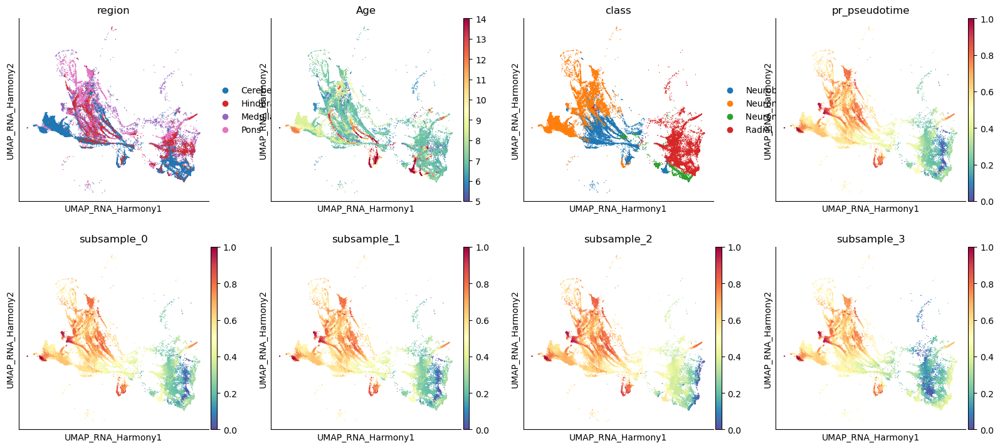

In [ ]:
sc.pl.embedding(adata_Hindbrain, basis="umap", 
                color=['region', 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Hindbrain_v3_05282026.png')
sc.pl.embedding(adata_Hindbrain, basis="UMAP_RNA_Harmony", 
                color=['region', 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Hindbrain_v3_05282026.png')


Processing column: subsample_0
Processing column: subsample_1
Processing column: subsample_2
Processing column: subsample_3
Processing column: pr_pseudotime


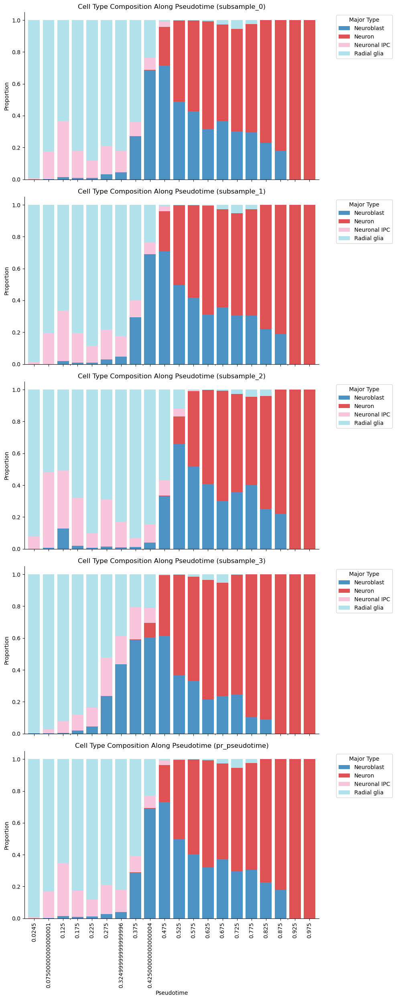

In [ ]:
num_cols = len(df.columns)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols), sharex=True)

# If there's only one column, adjust for 1D array issue
if num_cols == 1:
    axes = [axes]

# Iterate through each column in df and generate composition plots in subplots
for idx, col in enumerate(df.columns):
    print(f"Processing column: {col}")

    # Create pseudotime bins
    adata_Hindbrain.obs['pseudotime_bin'] = pd.cut(df[col], bins=num_bins)

    # Compute composition
    composition = (
        adata_Hindbrain.obs.groupby(['pseudotime_bin', 'class'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)  # Normalize to proportions
    )

    # Convert bin intervals to bin centers
    bin_centers = [interval.mid for interval in composition.index.categories]
    composition.index = bin_centers[:len(composition)]  # Ensure alignment

    # Plot composition in the respective subplot
    composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8, ax=axes[idx])
    axes[idx].set_title(f'Cell Type Composition Along Pseudotime ({col})')
    axes[idx].set_xlabel('Pseudotime')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    # axes[idx].grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/05282026/{region}_Hindbrain_composition_v3_05282026.png')

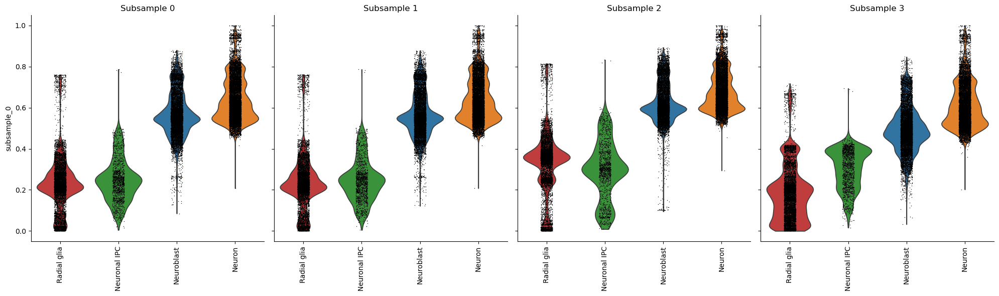

In [38]:
num_subsamples = 4
fig, axes = plt.subplots(nrows=1, ncols=num_subsamples, figsize=(5 * num_subsamples, 6), sharey=True)
for i in range(num_subsamples):
    ax = axes[i] if num_subsamples > 1 else axes  
    sc.pl.violin(
        adata_Hindbrain[mask],
        keys=[f"subsample_{i}"],
        groupby="class",
        rotation=90,
        order=trajectory,
        show=False,
        ax=ax  
    )

    ax.set_title(f"Subsample {i}")
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/01272025/{region}_Hindbrain_violin_subsample_pt_v3_01272025.png')

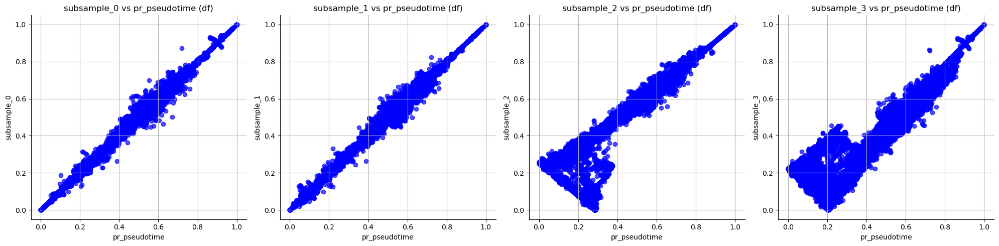

In [39]:
import matplotlib.pyplot as plt

num_cols = len(df.columns) - 1
fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(5 * num_cols, 5), sharex=True, sharey=False)
if num_cols == 1:
    axes = [axes]
col_index = 0 
for col in df.columns:
    if col != "pr_pseudotime":
        axes[col_index].scatter(df["pr_pseudotime"], df[col], color='blue', alpha=0.7)
        axes[col_index].set_title(f"{col} vs pr_pseudotime (df)")
        axes[col_index].set_xlabel("pr_pseudotime")
        axes[col_index].set_ylabel(col)
        axes[col_index].grid(True)

        col_index += 1
plt.tight_layout()
plt.show()

filename = f'./figures_logCPM/{region}/01272025/{region}_Hindbrain_comparison_w_lineage_specific_pt_v3_01272025.png'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [40]:
# del adata_Hindbrain

# Midbrain

In [44]:
adata_Midbrain = adata[adata.obs['mainRegion'] == 'Midbrain'].copy()
# adata_Midbrain.write_h5ad('Midbrain.h5ad')


In [45]:
sc.pp.neighbors(adata_Midbrain,use_rep='X_harmony', n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=42)
sc.tl.umap(adata_Midbrain)

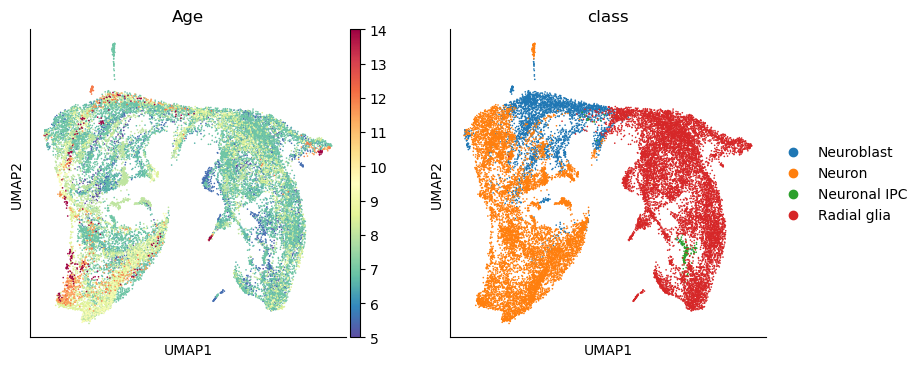

In [46]:
sc.pl.embedding(adata_Midbrain, basis="umap", 
                color=['Age', 'class'], )

(267,)
10X178_5:TGTTTGTTCAAATGAG


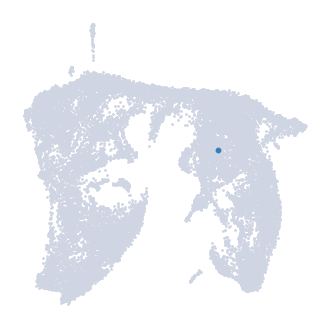

In [49]:
condition = np.where((adata_Midbrain.obs['Age']==np.min(adata_Midbrain.obs['Age']))&
                     (adata_Midbrain.obs['class']=='Radial glia'))[0]
print(condition.shape)
start_cell = adata_Midbrain.obs_names[condition[-1]]
print(start_cell)
palantir.plot.highlight_cells_on_umap(adata_Midbrain, [start_cell])
plt.show()

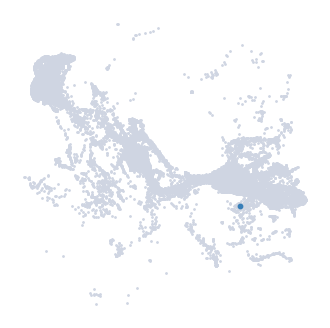

In [48]:
palantir.plot.highlight_cells_on_umap(adata_Midbrain, [start_cell],embedding_basis='X_UMAP_RNA_Harmony')
plt.show()

In [50]:
sce.tl.palantir(adata_Midbrain, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Midbrain,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
print(pr_res.pseudotime)
adata_Midbrain.obs['pr_pseudotime']=pr_res.pseudotime

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.015627702077229817 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.426629368464152 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
10X298_6:AACGAAAGTATCGAGG    0.652018
10X298_6:AGGATAAAGAGAGAAC    0.359842
10X298_6:CACATGACAGAGAATT    0.629561
10X298_6:CATGAGTCAAGCGCAA    0.290219
10X298_6:CTAGGTAGTCGTTCAA    0.265481
                               ...   
10X126_3:GCTCTGTAGCCACTAT    0.159234
10X126_3:GGAACTTAGTGAACGC    0.256459
10X126_3:GTGCATATCGTTACGA    0.249029
10X126_3:TCTGAGATCAAACCGT    0.281277
10X126_3:TGACTAGTCGGTCTAA    0.198401
Length: 21940, dtype: float64


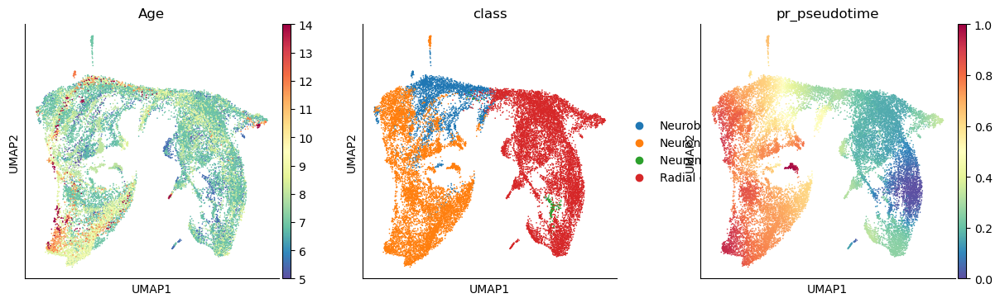

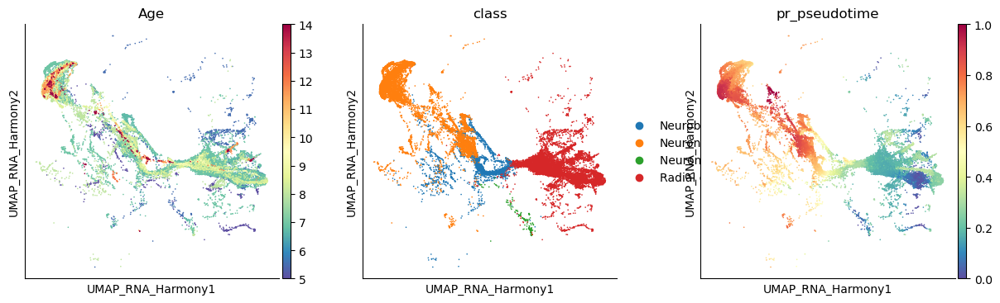

In [51]:
sc.pl.embedding(adata_Midbrain, basis="umap", 
                color=['Age', 'class','pr_pseudotime'], )
sc.pl.embedding(adata_Midbrain, basis="UMAP_RNA_Harmony", 
                color=['Age', 'class','pr_pseudotime'], )

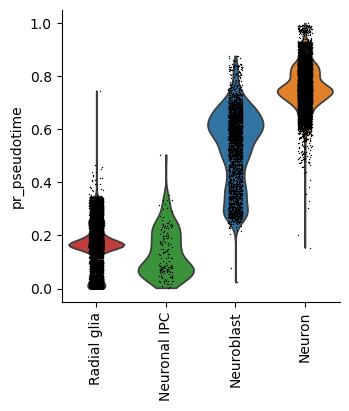

In [52]:
trajectory = ['Radial glia', 'Neuronal IPC','Neuroblast','Neuron']
# plot the Monocyte trajectory
mask = np.in1d(adata_Midbrain.obs["class"], trajectory)
sc.pl.violin(
    adata_Midbrain[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
    save=f"_{region}_Midbrain_v3_01272025.png"
)

<Figure size 1000x300 with 0 Axes>

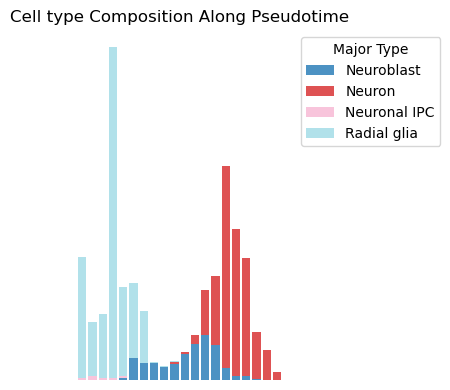

In [53]:
num_bins = 20
adata_Midbrain.obs['pseudotime_bin'] = pd.cut(adata_Midbrain.obs['pr_pseudotime'], bins=num_bins)
composition = (
    adata_Midbrain.obs.groupby(['pseudotime_bin', 'class'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x, axis=1)  # Normalize to proportions
)
bin_centers = [interval.mid for interval in composition.index.categories]
composition.index = bin_centers[:len(composition)]  # Ensure alignment


plt.figure(figsize=(10, 3))
composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8)
plt.title('Cell type Composition Along Pseudotime')
plt.axis("off")
plt.xlabel('Pseudotime')
plt.ylabel('Proportion')
plt.legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

(267,)
10X178_5:TCGGTCTAGACCATGG


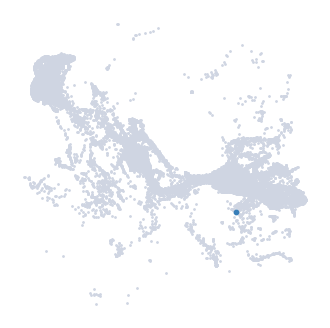

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.015820817152659098 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.4360475142796834 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.65539806 0.36273797 0.62956585 ... 0.25012659 0.28272399 0.19946505]
Done
(267,)
10X178_5:AAGTTCGAGGATATAC


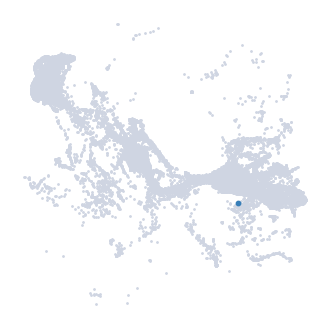

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.015703598658243816 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.42087416648864745 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.65060492 0.35880626 0.63108222 ... 0.248683   0.28115484 0.1981923 ]
Done
(267,)
10X178_5:ACACGCGAGCGTTACT


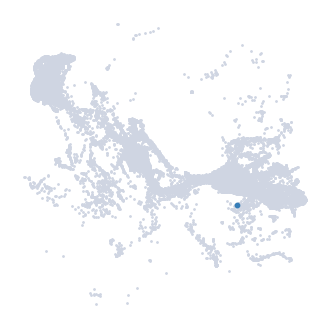

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.01601405143737793 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.44205191532770793 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.65235065 0.35889798 0.62768033 ... 0.2490784  0.28220048 0.19823112]
Done
(267,)
10X178_5:ACCCTCAGTATAATGG


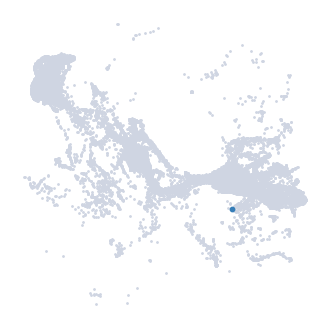

/Users/jiesheng/opt/anaconda3/envs/scanpy_env/lib/python3.12/site-packages/palantir/utils.py:468: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.015552333990732829 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.44388026793797813 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[0.65271226 0.35807711 0.63189658 ... 0.24861379 0.28367384 0.19877683]
Done


In [54]:
Midbrain_results = subsample_and_analyze(adata_Midbrain, n_pcs=n_pcs, n_neighbors=n_neighbors, cell_idx=condition)
df = pd.DataFrame({
    key: pd.Series(value) for subsample in Midbrain_results for key, value in subsample.items()})
df.index = adata_Midbrain.obs_names.values
df['pr_pseudotime'] = adata_Midbrain.obs['pr_pseudotime']
df.to_csv(f'Harmony_pr_psueotime_rep4_{region}_Midbrain_v3_01272025.csv')

adata_Midbrain.obs['subsample_0'] = df['subsample_0']
adata_Midbrain.obs['subsample_1'] = df['subsample_1']
adata_Midbrain.obs['subsample_2'] = df['subsample_2']
adata_Midbrain.obs['subsample_3'] = df['subsample_3']

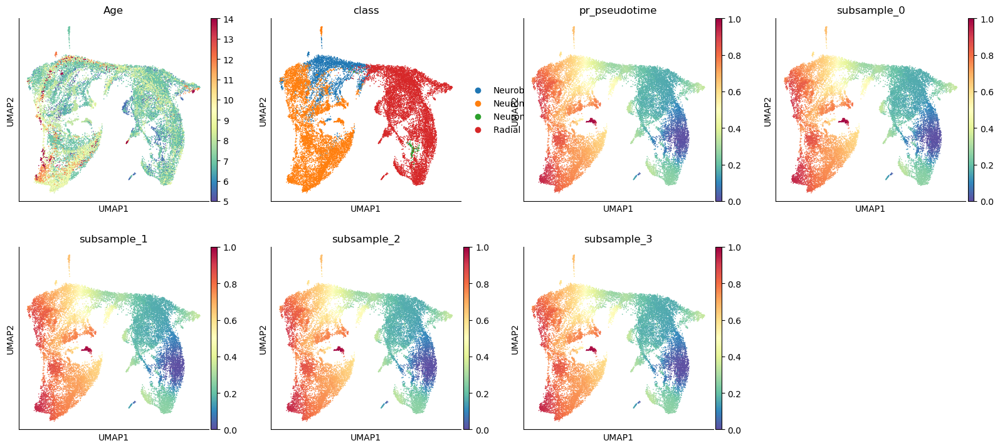

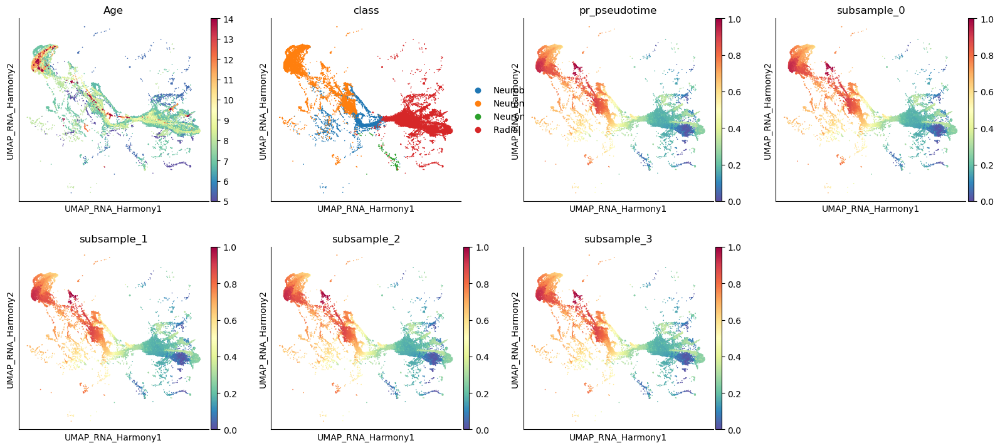

In [55]:
sc.pl.embedding(adata_Midbrain, basis="umap", 
                color=[ 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Midbrain_v3_01272025.png')
sc.pl.embedding(adata_Midbrain, basis="UMAP_RNA_Harmony", 
                color=[ 'Age', 'class','pr_pseudotime',
                      'subsample_0','subsample_1','subsample_2','subsample_3'],
                save=f'_{region}_Midbrain_v3_01272025.png')

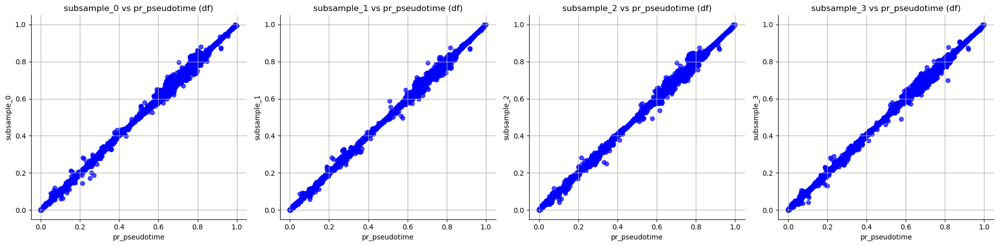

In [56]:
import matplotlib.pyplot as plt

num_cols = len(df.columns) - 1
fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(5 * num_cols, 5), sharex=True, sharey=False)
if num_cols == 1:
    axes = [axes]
col_index = 0 
for col in df.columns:
    if col != "pr_pseudotime":
        axes[col_index].scatter(df["pr_pseudotime"], df[col], color='blue', alpha=0.7)
        axes[col_index].set_title(f"{col} vs pr_pseudotime (df)")
        axes[col_index].set_xlabel("pr_pseudotime")
        axes[col_index].set_ylabel(col)
        axes[col_index].grid(True)

        col_index += 1
plt.tight_layout()
plt.show()

filename = f'./figures_logCPM/{region}/01272025/{region}_Midbrain_comparison_w_lineage_specific_pt_v3_01272025.png'
fig.savefig(filename, dpi=300, bbox_inches='tight')

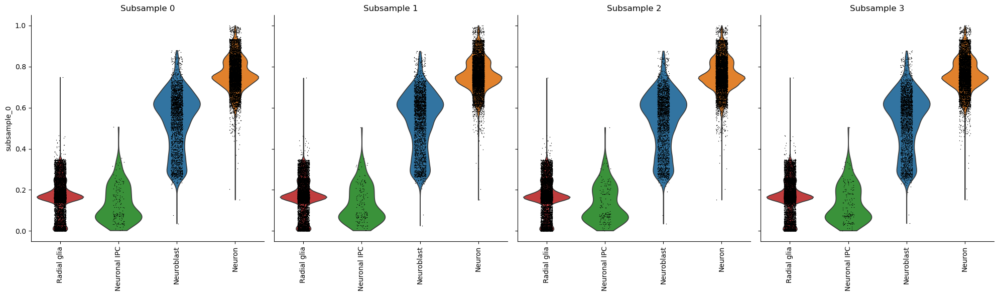

In [57]:
num_subsamples = 4
fig, axes = plt.subplots(nrows=1, ncols=num_subsamples, figsize=(5 * num_subsamples, 6), sharey=True)
for i in range(num_subsamples):
    ax = axes[i] if num_subsamples > 1 else axes  
    sc.pl.violin(
        adata_Midbrain[mask],
        keys=[f"subsample_{i}"],
        groupby="class",
        rotation=90,
        order=trajectory,
        show=False,
        ax=ax  
    )

    ax.set_title(f"Subsample {i}")
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/01272025/{region}_Midbrain_violin_subsample_pt_v3_01272025.png')

Processing column: subsample_0
Processing column: subsample_1
Processing column: subsample_2
Processing column: subsample_3
Processing column: pr_pseudotime


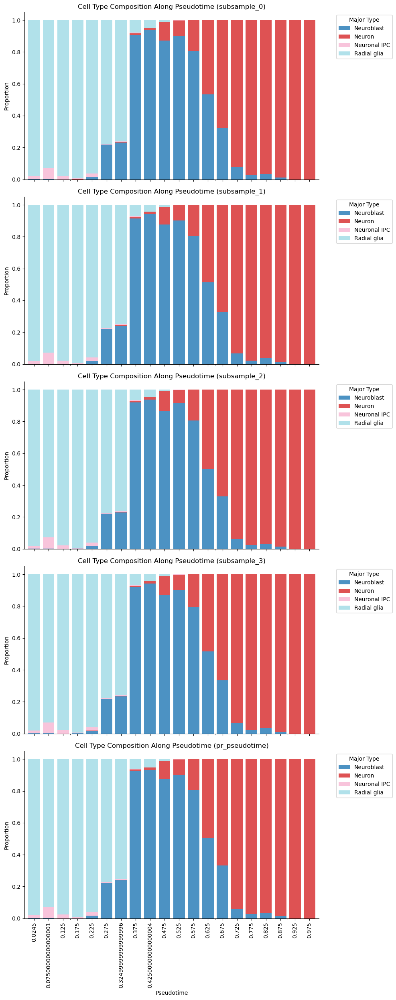

In [58]:
num_cols = len(df.columns)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 5 * num_cols), sharex=True)

# If there's only one column, adjust for 1D array issue
if num_cols == 1:
    axes = [axes]

# Iterate through each column in df and generate composition plots in subplots
for idx, col in enumerate(df.columns):
    print(f"Processing column: {col}")

    # Create pseudotime bins
    adata_Midbrain.obs['pseudotime_bin'] = pd.cut(df[col], bins=num_bins)

    # Compute composition
    composition = (
        adata_Midbrain.obs.groupby(['pseudotime_bin', 'class'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum(), axis=1)  # Normalize to proportions
    )

    # Convert bin intervals to bin centers
    bin_centers = [interval.mid for interval in composition.index.categories]
    composition.index = bin_centers[:len(composition)]  # Ensure alignment

    # Plot composition in the respective subplot
    composition.plot(kind='bar', stacked=True, alpha=0.8, colormap='tab20', width=0.8, ax=axes[idx])
    axes[idx].set_title(f'Cell Type Composition Along Pseudotime ({col})')
    axes[idx].set_xlabel('Pseudotime')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(title='Major Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    # axes[idx].grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
fig.savefig(f'./figures_logCPM/{region}/01272025/{region}_Midbrain_composition_v3_01272025.png')

In [96]:
# del adata_Midbrain

# w

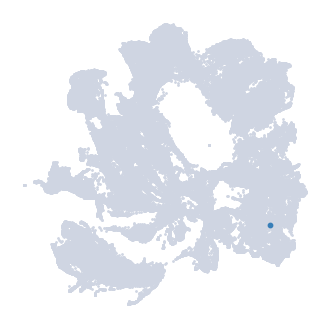

In [6]:
import palantir
import matplotlib.pyplot as plt
start_cell = adata.obs_names[np.where(adata.obs['class']=='Radial glia')[0][12000]]
palantir.plot.highlight_cells_on_umap(adata, [start_cell],embedding_basis='X_UMAP_RNA_Harmony')
plt.show()

In [7]:
import palantir
sce.tl.palantir(adata, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
adata.obs['pr_pseudotime']=pr_res.pseudotime

/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/palantir/utils.py:465: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.3341068466504415 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 8.010339816411337 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


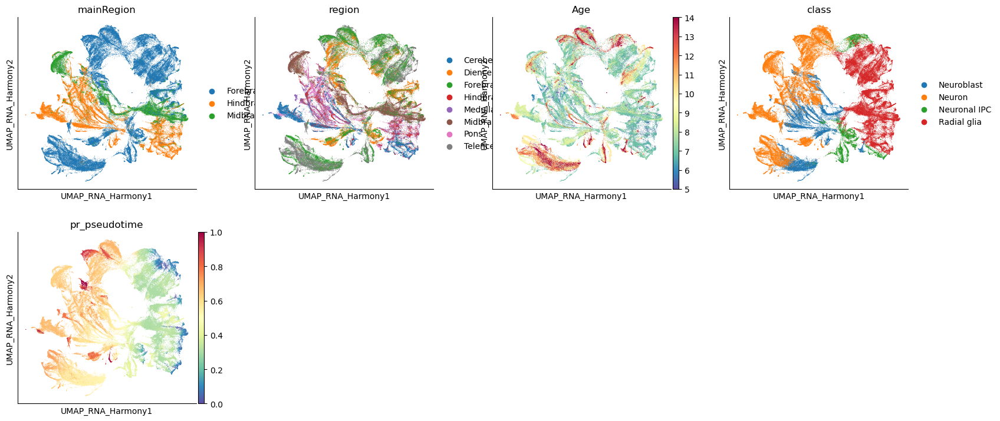

In [8]:
sc.pl.embedding(adata, basis="UMAP_RNA_Harmony", 
                color=['mainRegion', 'region', 'Age', 'class','pr_pseudotime'], )

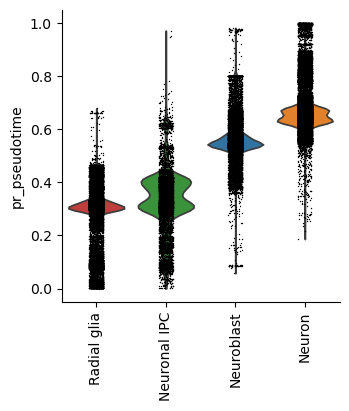

In [10]:
trajectory = ["Radial glia",'Neuronal IPC', 'Neuroblast','Neuron']
mask = np.in1d(adata.obs["class"], trajectory)
sc.pl.violin(
    adata[mask],
    keys=["pr_pseudotime"],
    groupby="class",
    rotation=90,
    order=trajectory,
)

In [11]:
adata_Forebrain=sc.read_h5ad('Forebrain.h5ad')
adata_Forebrain

AnnData object with n_obs × n_vars = 75180 × 4998
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellCycleFraction', 'DoubletFlag', 'DoubletScore', 'Subdivision', 'Subregion', 'Tissue', 'TopLevelCluster', 'TotalUMIs', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'total_UMIs', 'sample_id', 'cluster_id', 'class', 'region', 'donor', 'sample', 'cell_ID.1', 'OldCellID', 'n_genes', 'mainRegion', 'Age'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'class_colors', 'mainRegion_colors', 'neighbors', 'region_colors'
    obsm: 'X_PCA_for_Harmony', 'X_UMAP_RNA_Harmony', 'X_UMAP_RNA_Harmony_3D', 'X_harmony'
    varm: 'HARMONY', 'PCA_FOR_HARMONY'
    obsp: 'connectivities', 'distances'

In [104]:
region = 'Forebrain'

In [ ]:
n_pcs=50
n_neighbors=30
sc.pp.neighbors(adata_Forebrain,n_neighbors = n_neighbors, n_pcs=n_pcs, random_state=0, use_rep='X_harmony')

In [79]:
sc.tl.umap(adata_Forebrain)

/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


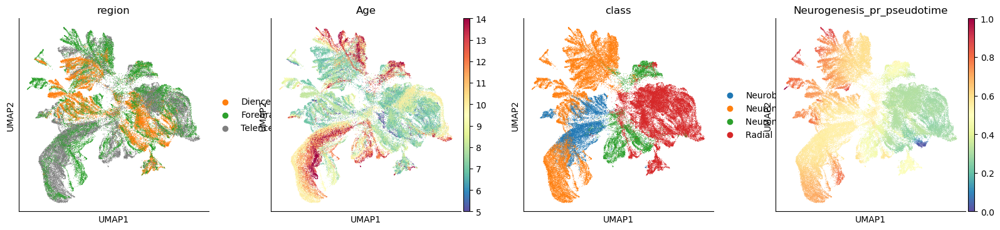

In [80]:
sc.pl.embedding(adata_Forebrain, basis="umap", 
                color=[ 'region', 'Age', 'class',f'{region}_pr_pseudotime'], )

In [82]:
max_index = np.argmax(adata_Forebrain.obsm['X_umap'][:, 0])
adata_Forebrain.obs['class'][max_index]

'Radial glia'

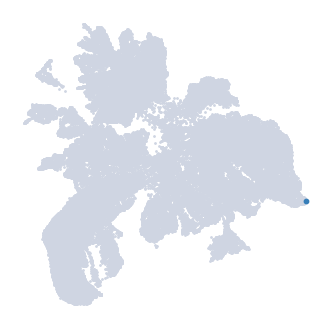

In [84]:
import palantir
import matplotlib.pyplot as plt
start_cell = adata_Forebrain.obs_names[max_index]
palantir.plot.highlight_cells_on_umap(adata_Forebrain, [start_cell],embedding_basis='X_umap')
plt.show()

In [85]:
import palantir
sce.tl.palantir(adata_Forebrain, n_components=n_pcs, use_adjacency_matrix=True)
pr_res = sce.tl.palantir_results(
    adata_Forebrain,
    early_cell=start_cell,
    # terminal_states=terminal_states,
    ms_data='X_palantir_multiscale',)
adata_Forebrain.obs[f'{region}_pr_pseudotime']=pr_res.pseudotime

/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/palantir/utils.py:465: UserWarning: 'data' is a sparse matrix and will be interpreted as kernel. To avoid this warning compute diffusion maps from a precompued kernel using palantir.utils.diffusion_maps_from_kernel().
  warn(


Sampling and flocking waypoints...
Time for determining waypoints: 0.22950878938039143 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 6.118994390964508 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9995
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


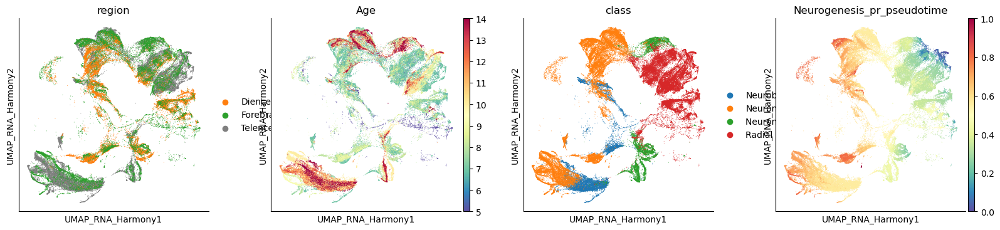

In [86]:
sc.pl.embedding(adata_Forebrain, basis="UMAP_RNA_Harmony", 
                color=[ 'region', 'Age', 'class',f'{region}_pr_pseudotime'], )

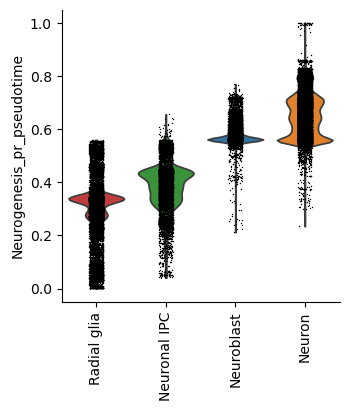

In [87]:
trajectory = ["Radial glia",'Neuronal IPC', 'Neuroblast','Neuron']
mask = np.in1d(adata_Forebrain.obs["class"], trajectory)
sc.pl.violin(
    adata_Forebrain[mask],
    keys=[f'{region}_pr_pseudotime'],
    groupby="class",
    rotation=90,
    order=trajectory,
)

  0%|          | 0/75180 [00:00<?, ?cell/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 11 SEGV: Segmentation Violation, probably memory access out of range
[0]PETSC ERROR: 

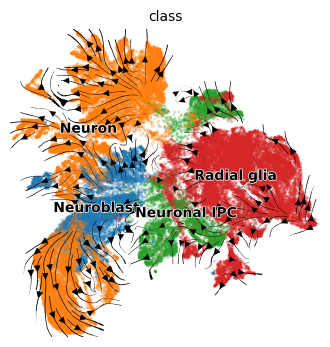

In [88]:
pk = cr.kernels.PseudotimeKernel(adata_Forebrain, time_key=f'{region}_pr_pseudotime')
pk.compute_transition_matrix()#frac_to_keep=0.5,threshold_scheme="soft", nu=0.5)
pk.plot_projection(basis="umap",color='class')

In [97]:
from cellrank.estimators import GPCCA
g = GPCCA(pk)
g.fit(cluster_key="class", n_states=[4,10])

GPCCA[kernel=PseudotimeKernel[n=75180], initial_states=None, terminal_states=None]

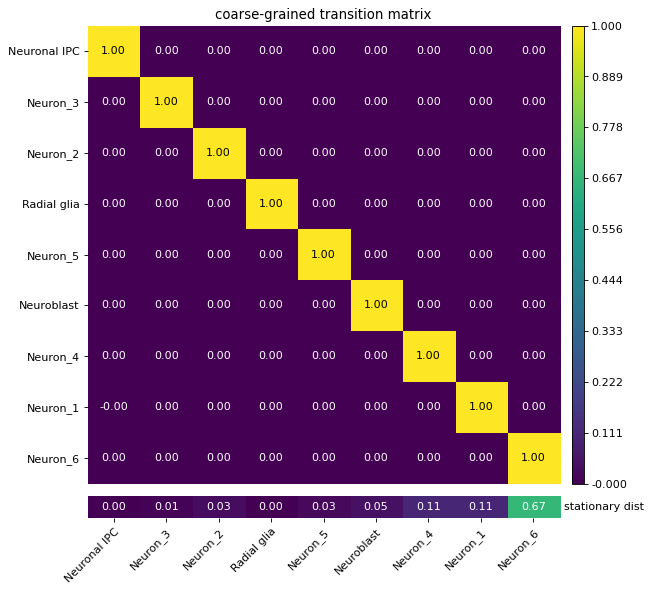

In [99]:
g.plot_coarse_T()

In [100]:
g.predict_terminal_states(method='top_n',n_states=2)

GPCCA[kernel=PseudotimeKernel[n=75180], initial_states=None, terminal_states=['Neuron_1', 'Neuron_6']]

In [101]:
g.compute_fate_probabilities(preconditioner='ilu',tol=1e-20)

  0%|          | 0/2 [00:00<?, ?/s]

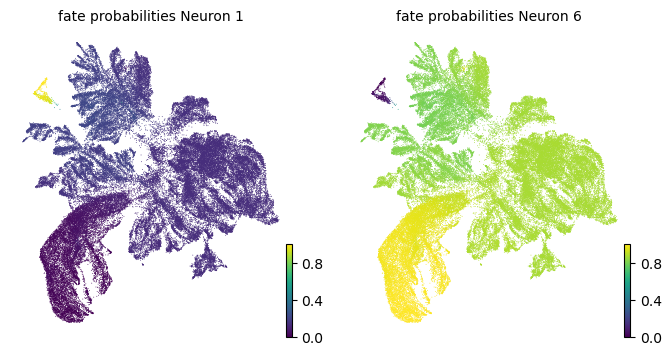

/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scvelo/plotting/scatter.py:614: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scvelo/plotting/scatter.py:614: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


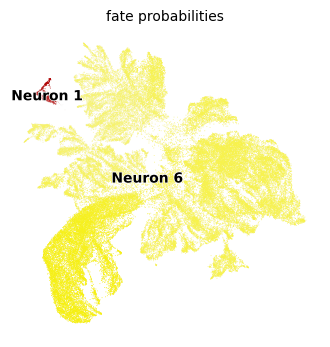

In [102]:
basis = 'umap'
g.plot_fate_probabilities(same_plot=False,  basis = basis)
g.plot_fate_probabilities(basis = basis)

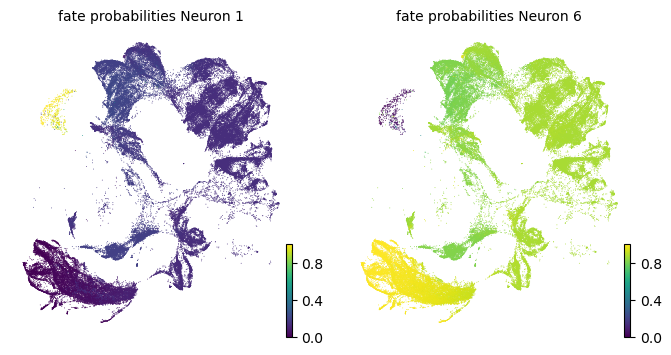

/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scvelo/plotting/scatter.py:614: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/ua/jsheng27/miniconda3/envs/cellrank_env/lib/python3.8/site-packages/scvelo/plotting/scatter.py:614: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


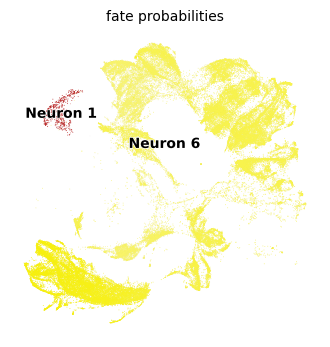

In [103]:
basis = 'UMAP_RNA_Harmony'
g.plot_fate_probabilities(same_plot=False,  basis = basis)
g.plot_fate_probabilities(basis = basis)